# Spoken Wiki attentional word recognition pilot task results

In [1]:
import pickle
import numpy as np 
import re 
from pathlib import Path
import pandas as pd
import json
import pickle

%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
# from matplotlib.ticker import FormatStrFormatter



/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "






### Import human data

In [8]:
path_to_human_data = Path('/mindhive/mcdermott/www/imgriff/msjspsych/')
# !ls {path_to_human_data}
# full paths to .json files 
human_fnames = list(path_to_human_data.glob("cocktail_party_word_recognition/data/*.json"))
# human_fnames = list(path_to_human_data.glob("cocktail_party_word_recognition/data/*.json"))

# import vocab dict for matching audio & responses 
# word_and_speaker_encodings = pickle.load( open("/om2/user/imgriff/projects/Auditory-Attention/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
# # ix_to_word_map = {v:k for k,v in class_map.items()}
# class_map = word_and_speaker_encodings['word_idx_to_word']
len(human_fnames)

46

In [9]:
any(["654110840e6a9717486c8aa2" in name.stem for name in human_fnames])

False

## Process Human Results

In [92]:
## Get all subject data into one df for analysis

def get_part_df(fname):
    part_data = json.load(open(fname, 'r'))
    # print(f"{fname.stem} success {part_data[0]['success']}")
    part_df = pd.DataFrame.from_records(part_data)
    ## Forward fill stim presentation entry to word response entry
    responses = part_df.loc[part_df.trial_type.isin(['audio-keyboard-response','dictionary-text']), ['trial_index', 'stimulus']]
    responses = responses.ffill()
    part_df.loc[part_df['trial_index'].isin(responses["trial_index"].values), 'stimulus'] = responses.stimulus
    return part_df

dfs = []
for fname in human_fnames:
    try:
        dfs.append(get_part_df(fname))
    except Exception as e:
        print(e)
        print(fname)
    
# results_df = pd.concat([get_part_df(fname) for fname in human_fnames], axis=0, ignore_index=True)
results_df = pd.concat(dfs)

## Filter for those who passed headphone check 
results_df = results_df[results_df.hc_passed == True]


## Add snr and condition names as columns - unpack from file code in file names 

import re
# get cond name map
map_path = Path('/om2/user/imgriff/projects/Auditory-Attention/human_saddler_attn_expmt_cond_map.pkl')
with open(map_path, 'rb') as handle:
    stim_cond_map = pickle.load(handle)

stim_cond_map = {f"condition_{k:02}": v for k,v in stim_cond_map.items()}

## Map wav str to stim_type using condition dict
def get_stim_snr_and_cond(stim_str, stim_cond_map=stim_cond_map):
    condition, snr = None,  None 
    if isinstance(stim_str, str) and not stim_str.startswith('<'):
        # print(stim_str)
        cond_str = re.search("condition_(-?\d+)", stim_str)
        if cond_str:
            cond_str = cond_str.group(0)
            condition, snr = stim_cond_map[cond_str]
        elif 'catch' in stim_str:
            condition = 'catch_trial'
            snr = np.inf
    return snr, condition

# add as columns 
results_df['snr'], results_df['condition'] = zip(*results_df['stimulus'].apply(get_stim_snr_and_cond))

# cut down df to only have trial answers (remove other meta data)
expmnt_trial_str = "dictionary-text"
trial_results = results_df[results_df.trial_type == expmnt_trial_str]

# Convert condition names to  readable format 
test_condition_dict = {'music':"background_musdb18hq",
                       "babble":"background_cv08talkerbabble",
                       "stationary": "background_issnstationary",
                       "modulated": "background_issnfestenplomp",
                       "audioset": "background_audioset",
                       "natural scene": "background_ieeeaaspcasa",
                       "clean": "SILENCE"}

condition_map = {v:k for k,v in test_condition_dict.items()}
trial_results['condition'] = trial_results['condition'].replace(condition_map)


# screen based on completion 
total_trials = 100
full_run_subjects = [subj_id for subj_id, did_all_trials in (trial_results.groupby('id_subject').condition.count() >= total_trials).items() if did_all_trials == True]
trial_results = trial_results[trial_results.id_subject.isin(full_run_subjects)]

# Add accuracy 
trial_results['accuracy'] = (trial_results['response'] == trial_results['correct_response']).astype('int')


Expecting value: line 1 column 83769 (char 83768)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition/data/subj_5cb20f2d7c917b00172dfef5.json
Unterminated string starting at: line 1 column 382653 (char 382652)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition/data/subj_629f6b8c65fcae219e245284.json
Unterminated string starting at: line 1 column 382854 (char 382853)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition/data/subj_60a3304ffb8cf482f8d11b6f.json
Unterminated string starting at: line 1 column 59805 (char 59804)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition/data/subj_63d1c3aec175ba81e9f50cf9.json


/tmp/ipykernel_2435087/2024411200.py:69: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trial_results['condition'] = trial_results['condition'].replace(condition_map)
/tmp/ipykernel_2435087/2024411200.py:78: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trial_results['accuracy'] = (trial_results['response'] == trial_results['correct_response']).astype('int')


In [93]:
catch_trial_particiapnt_performance = trial_results[trial_results.condition == 'catch_trial'].groupby('id_subject').accuracy.mean()
# catch_trial_particiapnt_performance


In [94]:
print("N total participants ", len(catch_trial_particiapnt_performance))
good_participants = catch_trial_particiapnt_performance[catch_trial_particiapnt_performance >= 11/12].index
print("N good participants ", len(good_participants))

good_results = trial_results[trial_results.id_subject.isin(good_participants)]

N total participants  27
N good participants  25


In [95]:
analysis_df = good_results[(~good_results.condition.isnull()) & (~good_results.response.isna())]
# analysis_df.groupby('id_subject').condition.count()


## Add re-scored performance based on entries included in excerpt transcripts  

In [96]:
# manifests[manifests.base_str == 'stim/condition_39/346.wav']

In [97]:
# w_tscrpt[w_tscrpt.target_transcript.isna()].stimulus

In [98]:
## Will add columns 'base_str', 'target_gender', 'target_f0', 'distractor_f0', 'distractor_gender' from manifests to trial_results where trial_results.stimulus == manifests.base_str

# manifests = pd.read_pickle("/om2/user/imgriff/projects/torch_2_aud_attn/swc_prolific_2023_single_distractor_ground_truth_manifest.pdpkl")
manifests = pd.read_pickle("/om2/user/imgriff/projects/torch_2_aud_attn/swc_prolific_2023_all_condition_ground_truth_manifest.pdpkl")

manifests['cond_folder'] = manifests['base_str'].apply(lambda x: x.split('/')[1])

analysis_df = pd.merge(analysis_df,
                        manifests[['base_str', 'target_gender', 'target_f0', 'distractor_f0', 'distractor_gender', 'distractor_word', 'target_transcript', 'distractor_transcript']],
                                    left_on='stimulus', right_on='base_str', how='left')
analysis_df['confusions'] = (analysis_df.response == analysis_df.distractor_word).astype('int')


# add adjusted accuracy and confusions 
pred_words = analysis_df.response.values
target_words = analysis_df.correct_response.values
distractor_words = analysis_df.distractor_word.values
target_transcripts = analysis_df.target_transcript.values
distractor_transcripts = analysis_df.distractor_transcript.values


adjusted_acc = np.array([int(pred_word in target_transcript or pred_word == target_word)
                            if not (isinstance(target_transcript, float) and target_word) else np.nan
                             for pred_word, target_word, target_transcript in zip(pred_words, target_words, target_transcripts)
                              ])

adjusted_confs = np.array([int(pred_word in distractor_transcript or pred_word == distractor_word)
                            if not (isinstance(distractor_transcript, float) and distractor_word) else np.nan
                             for pred_word, distractor_word, distractor_transcript in zip(pred_words, distractor_words, distractor_transcripts)
                              ])

analysis_df['adjusted_accuracy'] = adjusted_acc
analysis_df['adjusted_confusions'] = adjusted_confs

f0_analysis_df = analysis_df[analysis_df.condition.isin([ "1-talker", 'clean'])]
f0_analysis_df['gender_cond'] = f0_analysis_df['target_gender'].values == f0_analysis_df['distractor_gender'].values
f0_analysis_df['gender_cond'] = f0_analysis_df['gender_cond'].replace({True: 'same', False: 'different'})
f0_analysis_df["abs_f0_diff"] = np.abs(f0_analysis_df.target_f0 - f0_analysis_df.distractor_f0)
f0_analysis_df["percent_f0_diff"] = f0_analysis_df.distractor_f0 / f0_analysis_df.target_f0 
    
# rename condition to background condition
f0_analysis_df = f0_analysis_df.rename(columns={"condition": "background_condition"})
f0_analysis_df = f0_analysis_df.dropna(axis=1,  how = 'all')
# get columns with trial in their name
trial_cols = [col for col in f0_analysis_df.columns if 'trial' in col]
# drop trial columns
f0_analysis_df = f0_analysis_df.drop(columns=trial_cols).reset_index(drop=True)


/tmp/ipykernel_2435087/1561485371.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  f0_analysis_df['gender_cond'] = f0_analysis_df['target_gender'].values == f0_analysis_df['distractor_gender'].values
/tmp/ipykernel_2435087/1561485371.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  f0_analysis_df['gender_cond'] = f0_analysis_df['gender_cond'].replace({True: 'same', False: 'different'})
/tmp/ipykernel_2435087/1561485371.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice 

In [99]:
# Adjusted accuracy should always greater than or equal to accuracy
analysis_df.loc[~(analysis_df['adjusted_accuracy'] >= analysis_df['accuracy']), ['response', 'correct_response', 'adjusted_accuracy', 'accuracy', "condition"]]

,response,correct_response,adjusted_accuracy,accuracy,condition
7,before,before,NaN,1,catch_trial
102,because,because,NaN,1,catch_trial
103,through,thing,NaN,0,catch_trial
107,world,world,NaN,1,catch_trial
133,point,point,NaN,1,catch_trial
...,...,...,...,...,...
8452,another,another,NaN,1,catch_trial
8473,being,being,NaN,1,catch_trial
8479,still,still,NaN,1,catch_trial
8533,first,first,NaN,1,catch_trial


In [100]:
to_check = analysis_df[analysis_df.condition!="catch_trial"]
(to_check.adjusted_accuracy >= to_check.accuracy).all()

True

In [101]:
# get trial data excluding catch trials 


part_summary_df = (analysis_df.groupby(["snr", 'id_subject', "condition"])
                     .agg({'correct':['mean', 'sem', 'count'],
                            'confusions':['mean', 'sem'],
                            'adjusted_accuracy':['mean', 'sem'],
                            'adjusted_confusions':['mean', 'sem']})
                     .reset_index())

part_summary_df['snr'] = part_summary_df['snr'].replace(np.inf, 6)
part_summary_df['snr'] =  part_summary_df['snr'].replace("inf", 6)
part_summary_df['snr'] = part_summary_df['snr'].astype('int')
# flatten multiindex 
part_summary_df.columns = ['_'.join(col).strip() for col in part_summary_df.columns.values]
# remove trailing underscore
part_summary_df.columns = [col[:-1] if col.endswith('_') else col for col in part_summary_df.columns.values]


In [102]:
# part_summary_df
# part_summary_df.to_pickle("2023_swc_attn_word_rec_prolific_good_parts_n_81.pdpkl")

In [103]:
# part_summary_df = pd.read_pickle("2023_swc_attn_word_rec_prolific_good_parts_n_81.pdpkl")

In [104]:

part_summary_df.head()

,snr,id_subject,condition,correct_mean,correct_sem,correct_count,confusions_mean,confusions_sem,adjusted_accuracy_mean,adjusted_accuracy_sem,adjusted_confusions_mean,adjusted_confusions_sem
0,-9,59f4a9477086f80001941298,1-talker,0.4,0.163299,10,0.1,0.1,0.7,0.152753,0.1,0.1
1,-9,59f4a9477086f80001941298,4-talker,0.1,0.100000,10,0.0,0.0,0.1,0.100000,NaN,NaN
2,-9,59f4a9477086f80001941298,babble,0.0,0.000000,10,0.0,0.0,0.0,0.000000,NaN,NaN
3,-9,59f4a9477086f80001941298,modulated,0.3,0.152753,10,0.0,0.0,0.4,0.163299,NaN,NaN
4,-9,59f4a9477086f80001941298,music,0.8,0.133333,10,0.0,0.0,0.9,0.100000,NaN,NaN


In [105]:
## Summarize participant data for aggregate plotting

summary_df = part_summary_df.groupby(['snr', 'condition']).agg({'correct_mean':['mean', 'sem'], 'confusions_mean':['mean', 'sem', 'count'],
                                                             'adjusted_accuracy_mean':['mean','sem'], 'adjusted_confusions_mean':['mean', 'sem']}).reset_index()
summary_df.columns = ['snr', 'background_condition', 'accuracy', 'acc_std_error', 'confusions', 'conf_std_error', 'N', 'adjusted_accuracy', 'adj_acc_std_error', 'adjusted_confusions', 'adj_conf_std_error']


In [106]:
# summary_df.to_pickle('2023_swc_attn_word_rec_prolific_summary_n_81.pdpkl')

## Load Model Results 

In [107]:
## import class maps
import pickle
## load WSN vocab mapping 
word_and_speaker_encodings = pickle.load( open( "/om2/user/imgriff/projects/Auditory-Attention/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
wsn_word_2_class = word_and_speaker_encodings['word_to_idx']
wsn_class_2_word = word_and_speaker_encodings['word_idx_to_word']
cv_word_2_class = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
cv_class_2_word = {v:k for k,v in cv_word_2_class.items()}


In [108]:
# manifests[manifests.condition == 'clean'].snr.iloc[0]

In [109]:
# manifests.background_condition

In [117]:

# model_names = ["word_task_mono_arch_v07", "word_task_diotic_arch_v07_gend_bal", "word_task_standard_v07", "word_task_half_co_loc_v07",
#              "word_task_mono_arch_v06", "attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor"]
             

# model_names = ["word_task_standard_v07", "word_task_standard_v07_gend_bal", "word_task_half_co_loc_v07",
#              "word_task_mono_arch_v06", "attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor"]
             

# model_names = ["word_task_standard_v07", "word_task_half_co_loc_v07", "word_task_20p_loc_v07_wider_SNR", 'word_task_20p_loc_v07_wider_SNR_residual_attn', "attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor"]
# model_names = ["word_task_standard_v08", "word_task_25p_loc_v07_LN_last_valid_time_no_affine"]
model_names = ["word_task_half_co_loc_v08_gender_bal_4M_sanity",]# "word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned"]
             
model_name_dict = {"attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor": "Mono WordSpeakerNoise",
                   "word_task_standard_v07_gend_bal": "Binaural CV gend bal no pitch aug.",
                   "word_task_mono_arch_v06": "Mono CommonVoice",
                   "word_task_half_co_loc_v07": "50% co-located v07",
                   "word_task_half_co_loc_v08":  "Standard v08",                                        # half_co_loc_v08 is actually just standard spatialization  
                   "word_task_standard_v07": "Binaural CV no pitch augments",
                   "word_task_standard_v08": "Binaural v08",
                   "word_task_half_co_loc_v08_70p_same": "Half co-loc 70p same-sex v08",
                   "word_task_mono_arch_v07": "Mono CV no pitch augments",
                   "word_task_diotic_arch_v07": "Diotic CV no pitch augments",
                   "word_task_diotic_arch_v07_gend_bal": "Diotic CV gend bal no pitch aug.",
                   "word_task_20p_loc_v07_wider_SNR": "25% co-located wider SNR", # are really 25% co-located
                   "word_task_20p_loc_v07_wider_SNR_residual_attn": "25% co-located wider SNR residual attn", # are really 25% co-located
                   "word_task_25p_loc_v07_LN_last_valid_time_no_affine": "25% co-located LN last valid time no affine",
                   "word_task_quarter_co_loc_v08": "v08 25% co-located",
                   "word_task_standard_v08_70p_same_dist": "70% same-sex distractor" ,
                   'word_task_v08_control_no_attn': 'Baseline CNN',
                   "word_task_gender_balanced_fc_1024_v08": "Gender Balanced large fc v08",
                   "word_task_half_co_loc_v08_gender_bal": "Gender Balanced v08",
                   "word_task_half_co_loc_v08_gender_bal_4M": "Gender Balanced v08 4M",
                   "word_task_half_co_loc_v08_gender_bal_4M_orig": "50% co-located v08 4M",
                   "word_task_half_co_loc_v08_gender_bal_4M_sanity": "50% co-located GB v08 4M",
                   "word_task_deep_fc_1024_v08": "Deeper Architecture",
                   "word_task_half_co_locate_deep_fc_1024_v08": "Deep Arch. 50% co-located",
                   "word_task_half_co_locate_deep_fc_1024_v08_old": "Deep Arch. 50% co. old ckpt",
                   "word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned": "learned no cue trials"
                  }


manifests = pd.read_pickle("/om2/user/imgriff/datasets/spatial_audio_pipeline/assets/human_attn_experiment_v00/screened_eval_trial_manifest_new_fnames_w_transcripts_and_f0.pdpkl")

manifests['test_index'] = manifests.index

all_model_results = []
all_model_f0_results = []

# Convert condition names to  readable format 
test_condition_dict = {'music':"background_musdb18hq",
                    "babble":"background_cv08talkerbabble",
                    "stationary": "background_issnstationary",
                    "modulated": "background_issnfestenplomp",
                    "audioset": "background_audioset",
                    "natural scene": "background_ieeeaaspcasa",
                    "clean": "SILENCE"}

str_to_cond = {v:k for k,v in test_condition_dict.items()}

# update gt manifests to match readable format 

for model_name in model_names:
    if "v0" in model_name:
        output_paths = list(Path(f'swc_mono_eval_full_stim/{model_name}').glob('*.csv'))
        print(len(output_paths))

    elif model_name == "attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor":
        output_paths = list(Path(f'../Auditory-Attention/swc_mono_eval/{model_name}').glob('*.csv'))
        print(len(output_paths))
    results_dfs = []


    for path in output_paths:
        df = pd.read_csv(path)
        # reformat dict
        df['model'] = path.parent.name
        #parts of name 
        parts = path.stem.split(path.parent.name)[-1].split('_')   
        # use re to split path.stem after model name and before <int>dB 
        if 'one_distractor' in path.stem:
            df['background_condition'] = '1-talker'
        elif 'four_distractor' in path.stem:
            df['background_condition'] = '4-talker'
        elif 'natural' in path.stem:
            df['background_condition'] = 'natural scene'
        else:
            df['background_condition'] = [k for k in test_condition_dict.keys() if k in path.stem][0]
    
        if 'clean' in path.stem:
            df['background_condition'] = 'clean'
            df['snr'] =  'inf' # really np.inf, 6 for plotting 
        else:
            df['snr'] = int(re.search('(-?\d+)dB', path.stem).group(0).strip('dB'))
        df['test_index'] = df.index
        df = pd.merge(df,
            manifests[["test_index", "word", "word_int", 'gender', 'target_f0', 'distractor_f0', 'distractor_gender', 'distractor_word', 'target_transcripts', 'distractor_transcripts']],
                        left_on=["test_index", "true_word_int"], right_on=["test_index", "word_int"])

        results_dfs.append(df)


    model_results = pd.concat(results_dfs, axis=0, ignore_index=True)
    model_str = model_name_dict[model_name]
    model_results['group'] = model_str
    ## Load in model vocab 
    class_2_word =  wsn_class_2_word if 'WordSpeakerNoise' in model_str else  cv_class_2_word
    model_results['pred_word'] = model_results['pred_word_int'].replace(class_2_word)
    model_results['true_word'] = model_results['true_word_int'].replace(class_2_word)


    # Add 1-talker condition metadata to model results

    # add confusions 
    model_results['confusions'] = (model_results.pred_word == model_results.distractor_word).astype('int')

    # add adjusted accuracy and confusions 
    pred_words = model_results.pred_word.values
    target_words = model_results.word.values
    target_transcripts = model_results.target_transcripts.values
    distractor_words = model_results.distractor_word.values
    distractor_transcripts = model_results.distractor_transcripts.values


    adjusted_acc = np.array([int(pred_word in target_transcript or pred_word == target_word)
                                if not isinstance(target_transcript, float) else np.nan
                                for pred_word, target_word, target_transcript in zip(pred_words, target_words, target_transcripts)
                                ])

    adjusted_confs = np.array([int(pred_word in distractor_transcript or pred_word == distractor_word)
                                if not isinstance(distractor_transcript, float) else np.nan
                                for pred_word, distractor_word, distractor_transcript in zip(pred_words, distractor_words, distractor_transcripts)
                                ])
    
    model_results['adjusted_accuracy'] = adjusted_acc
    model_results['adjusted_confusions'] = adjusted_confs
    
    all_model_results.append(model_results)

    model_f0_df = model_results[model_results.background_condition.isin([ "1-talker", 'clean'])]
    model_f0_df.loc[:, 'gender_cond'] = model_f0_df.apply(lambda row: 'same' if row['gender'] == row['distractor_gender'] else 'different', axis=1)
    model_f0_df.loc[model_f0_df.background_condition == 'clean', 'gender_cond'] = 'clean'
    model_f0_df.loc[:, "abs_f0_diff"] = np.abs(model_f0_df.target_f0 - model_f0_df.distractor_f0)
    model_f0_df.loc[:, "percent_f0_diff"] = model_f0_df.distractor_f0 / model_f0_df.target_f0 
    all_model_f0_results.append(model_f0_df)

all_model_results = pd.concat(all_model_results, axis=0, ignore_index=True)
all_model_f0_results = pd.concat(all_model_f0_results, axis=0, ignore_index=True)

43


/tmp/ipykernel_2435087/128880581.py:140: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_f0_df.loc[:, 'gender_cond'] = model_f0_df.apply(lambda row: 'same' if row['gender'] == row['distractor_gender'] else 'different', axis=1)
/tmp/ipykernel_2435087/128880581.py:142: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_f0_df.loc[:, "abs_f0_diff"] = np.abs(model_f0_df.target_f0 - model_f0_df.distractor_f0)
/tmp/ipykernel_2435087/128880581.py:143: SettingWithCopyWarning: 
A value is trying to be set on a c

In [118]:
# Adjusted accuracy should always greater than or equal to accuracy
(all_model_results['adjusted_accuracy'] >= all_model_results['accuracy']).all() 

True

In [119]:
all_model_results.snr.unique()

array([-12, -3, -6, -9, 0, 3, 'inf'], dtype=object)

In [124]:
N = int(summary_df.N.max())

summary_df['group'] = f'Participants (N={N})'
# model_results['group'] = 'model'
# all_model_results = all_model_results[all_model_results.snr > -12]
# combine model and participant results ignore missing columns
combined_results = pd.concat([summary_df, all_model_results], axis=0, ignore_index=True)

In [125]:
combined_results.loc[combined_results.snr == np.inf, 'snr'] = 6
combined_results.loc[combined_results.snr == 'inf', 'snr'] = 6
combined_results.snr = combined_results.snr.astype('int')
combined_results = combined_results[combined_results.snr > -12]

In [126]:
all_model_results.model.unique()

array(['word_task_half_co_loc_v08_gender_bal_4M_sanity'], dtype=object)

## Standard analysis 

Text(0.5, 1.05, 'Using single-word accuracy')

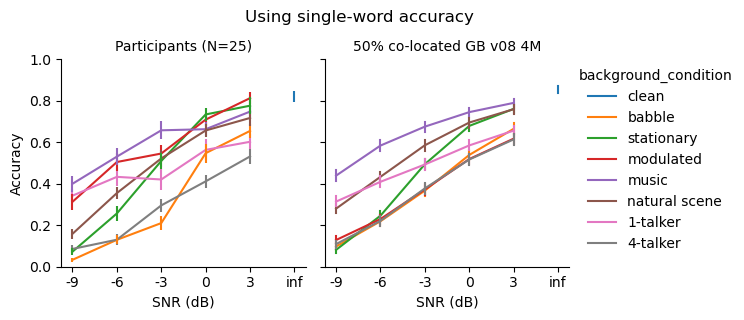

In [127]:
# to_plot = combined[(combined.condition!='audioset') & (combined.snr > -12)]
to_plot = combined_results[~combined_results.background_condition.isin(["catch_trial", 'audioset'])]

hue_order = ['clean', 'babble',  'stationary', 'modulated', 'music', 'natural scene', "1-talker", "4-talker"]

palette = dict(zip(hue_order, sns.color_palette(n_colors= len(hue_order), as_cmap=True)))

# add markers to relplot
g = sns.relplot(data=to_plot, x='snr', y='accuracy', col='group', hue='background_condition', hue_order=hue_order,
                # col_wrap=4,
                # style='model', style_order=['human', "attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor"],
                  kind='line', marker='', palette=palette, height=3, aspect=1, err_style='bars', errorbar=('ci', 95))
# g.map(plt.errorbar, "snr", "accuracy", "std_error", marker=None, ls='none')

# set labels 
g.set_axis_labels("SNR (dB)", "Accuracy")
g.set_titles("{col_name}")

# iterate through each facet of the facetgrid
for model, ax in g.axes_dict.items():
    # skip the model facet - we bootstrap above 
    if model == 'model':
        continue 
    # select the data for the facet
    data = to_plot[to_plot['group'].eq(model)]
    # select the data for each hue group
    for group, selected in data.groupby('background_condition'):
        # plot the errorbar with the correct color for each group 
        ax.errorbar(data=selected, x="snr", y="accuracy", yerr="acc_std_error", color=palette[group], marker=None, ls='none' )

x_tick_locs = to_plot.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)
plt.ylim(0,1)
plt.suptitle(f"Using single-word accuracy", y=1.05)
# plt.tight_layout()

(0.0, 1.0)

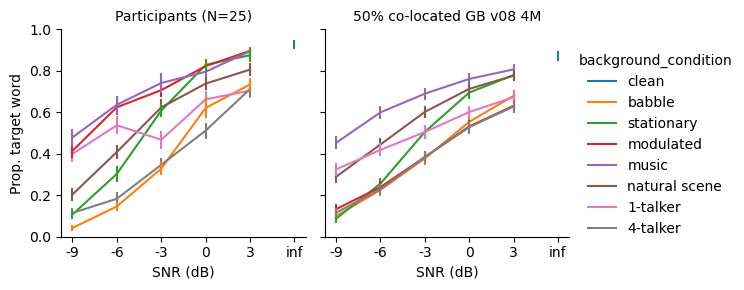

In [128]:
# to_plot = combined[(combined.condition!='audioset') & (combined.snr > -12)]
to_plot = combined_results[~combined_results.background_condition.isin(["catch_trial", 'audioset'])]

hue_order = ['clean', 'babble',  'stationary', 'modulated', 'music', 'natural scene', "1-talker", "4-talker"]

palette = dict(zip(hue_order, sns.color_palette(n_colors= len(hue_order), as_cmap=True)))
# to_plot = to_

# add markers to relplot
g = sns.relplot(data=to_plot, x='snr', y='adjusted_accuracy', col='group', hue='background_condition', hue_order=hue_order, #col_wrap=4,
                # style='model', style_order=['human', "attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor"],
                  kind='line', marker='', palette=palette, height=3, aspect=1, err_style='bars', errorbar=('se', 2))
# g.map(plt.errorbar, "snr", "accuracy", "std_error", marker=None, ls='none')

# set labels 
g.set_axis_labels("SNR (dB)", "Prop. target word")
g.set_titles("{col_name}")

# iterate through each facet of the facetgrid
for model, ax in g.axes_dict.items():
    # skip the model facet - we bootstrap above 
    if model == 'model':
        continue 
    # select the data for the facet
    data = to_plot[to_plot['group'].eq(model)]
    # select the data for each hue group
    for group, selected in data.groupby('background_condition'):
        # plot the errorbar with the correct color for each group 
        ax.errorbar(data=selected, x="snr", y="adjusted_accuracy", yerr="adj_acc_std_error", color=palette[group], marker=None, ls='none' )

x_tick_locs = to_plot.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)
plt.ylim(0,1)
# plt.suptitle(f"Using in-transcript accuracy", y=1.05)
# plt.tight_layout()

In [47]:
to_plot.model.unique()

array([nan, 'word_task_half_co_loc_v08_gender_bal_4M_sanity'],
      dtype=object)

In [48]:
to_plot[ (to_plot.background_condition == '1-talker') & (to_plot.snr == 0)].groupby(['group']).adjusted_accuracy.mean() # (to_plot.model=='word_task_25p_loc_v07_LN_last_valid_time_no_affine') &

group
50% co-located GB v08 4M    0.601132
Participants (N=23)         0.673913
Name: adjusted_accuracy, dtype: float64

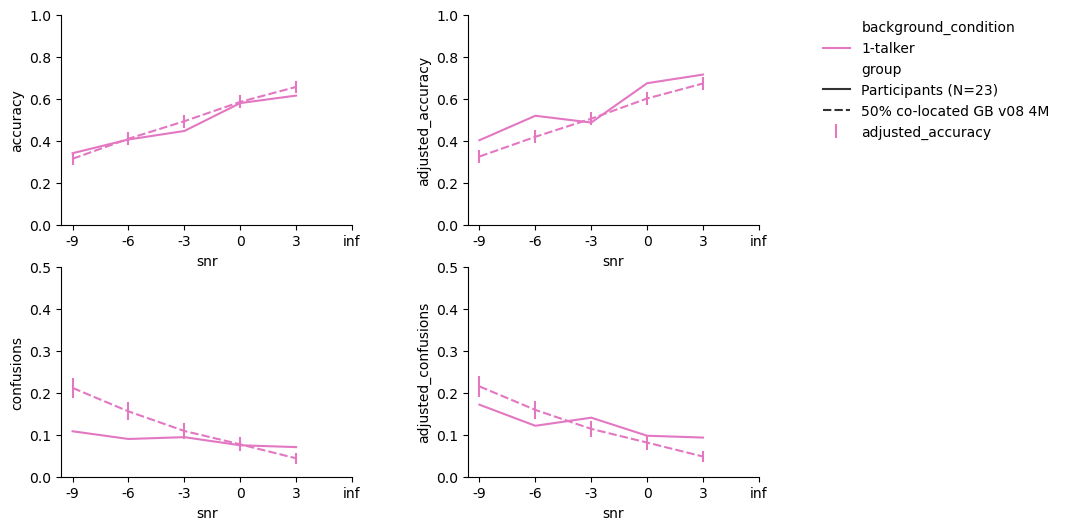

In [49]:
fig, axs = plt.subplots(2,2, figsize=(9,6))

to_plot = combined_results[combined_results.background_condition.isin(["1-talker"])]
# to_plot = to_plot.drop(columns=['target_transcript', 'distractor_transcript'])
# to_plot.drop_duplicates(inplace=True)

style_order = to_plot.group.unique()

# style_order = ['participants (N=81)', 'Diotic CommonVoice', 'Mono CommonVoice', 'Mono WordSpeakerNoise', 'Binaural CommonVoice', "Binaural Half-CoLocated CV"]


g = sns.lineplot(data=to_plot, x = 'snr', y = 'accuracy', err_style='bars', errorbar=('se', 2),
                  style='group', style_order=style_order, 
                  hue='background_condition', palette=palette,
            ax=axs[0,0])

g1 = sns.lineplot(data=to_plot, x = 'snr', y = 'adjusted_accuracy',  err_style='bars', errorbar=('se', 2),
                   style='group',style_order=style_order, 
                   hue='background_condition', palette=palette,
            ax=axs[0,1])


g2 = sns.lineplot(data=to_plot, x = 'snr', y = 'confusions', err_style='bars', errorbar=('se', 2),
                  style='group', style_order=style_order, 
                  hue='background_condition', palette=palette,
            ax=axs[1,0])

g3 = sns.lineplot(data=to_plot, x = 'snr', y = 'adjusted_confusions',  err_style='bars', errorbar=('se', 2),
                   style='group',style_order=style_order, 
                   hue='background_condition', palette=palette,
            ax=axs[1,1])

# add error bars for participants
# iterate through each facet of the facetgrid
ebar_data = to_plot[to_plot['group'].eq('participants')]
# select the data for each hue group
g.errorbar(data=selected, x="snr", y="accuracy", yerr="acc_std_error", color=palette["1-talker"], marker=None, ls='none' )
g2.errorbar(data=selected, x="snr", y="confusions", yerr="conf_std_error", color=palette["1-talker"], marker=None, ls='none' )

g1.errorbar(data=selected, x="snr", y="adjusted_accuracy", yerr="adj_acc_std_error", color=palette["1-talker"], marker=None, ls='none' )
g3.errorbar(data=selected, x="snr", y="adjusted_confusions", yerr="adj_conf_std_error", color=palette["1-talker"], marker=None, ls='none' )


g.set_xticks(ticks=x_tick_locs) # set new labels
g1.set_xticks(ticks=x_tick_locs) # set new labels
g2.set_xticks(ticks=x_tick_locs) # set new labels
g3.set_xticks(ticks=x_tick_locs) # set new labels
g.set_xticklabels(labels=x_tick_labels) # adj_acc_std_error
g1.set_xticklabels(labels=x_tick_labels)
g2.set_xticklabels(labels=x_tick_labels)
g3.set_xticklabels(labels=x_tick_labels)
g.set_ylim(0,1)
g1.set_ylim(0,1)
g2.set_ylim(0,.5)
g3.set_ylim(0,.5)

g.legend().remove()     
g2.legend().remove()
g3.legend().remove()

# add space between plots
plt.subplots_adjust(wspace=0.4)
sns.despine()

# remove legend titles 
g1.legend_.set_title('')
g1.legend(frameon=False, bbox_to_anchor=(1.2, 1), loc=2, borderaxespad=0., title='')


### Scatter plot of human vs model performance

In [50]:
from scipy import stats


clean
babble
stationary
modulated
music
natural scene
1-talker
4-talker


Text(0.5, 0.95, 'Using single-word scoring')

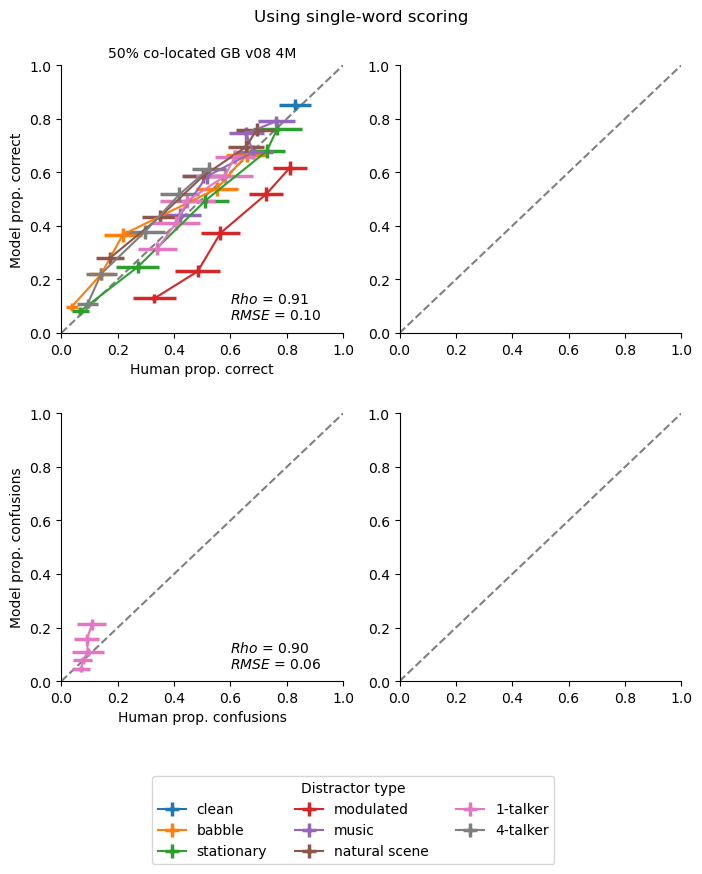

In [51]:
grouped_results = combined_results[~combined_results.background_condition.isin(["catch_trial", 'audioset'])]

hue_order = ['clean', 'babble', 'stationary', 'modulated', 'music', 'natural scene', "1-talker", "4-talker"]
palette = dict(zip(hue_order, sns.color_palette(n_colors= len(hue_order), as_cmap=True)))

x = y = np.linspace(0,1,5)

fontsize = 10

# model_list = ["Binaural CommonVoice", "Binaural Half-CoLocated CV", 'Mono CommonVoice', 'Diotic CommonVoice', 'Mono WordSpeakerNoise']
model_list = grouped_results.group.unique()[1:]

fig, axs = plt.subplots(2,len(model_list)+1, figsize=((4*(1+len(model_list))),8))

# for ix, group in enumerate(grouped_results.group.unique()):
# add dashed line to each subplot 
for ax in axs.flat:
    ax.plot(x,y, ls='dashed', color='grey')

human_df = grouped_results[grouped_results.group.str.contains('Participants')]
# get adjusted_confusion data
human_conf_data = human_df[human_df.background_condition ==  "1-talker"]
human_conf_means = human_conf_data["confusions"].values
human_conf_errors = human_conf_data["conf_std_error"].values * 2 # 95% CI

for ix, model in enumerate(model_list):
    model_df = grouped_results[grouped_results.group == model]
    # summarize model data
    model_df = model_df.groupby(['snr', 'background_condition']).agg({'accuracy': ['mean', 'sem',], 'confusions':['mean', 'sem'], 
                                                                        'adjusted_accuracy': ['mean', 'sem',], 'adjusted_confusions':['mean', 'sem', 'count']}).reset_index()
    # rename columns
    model_df.columns = ['snr', 'background_condition', 'accuracy', 'acc_std_error', 'confusions', 'conf_std_error', 'adjusted_accuracy', 'adj_acc_std_error', 'adjusted_confusions', 'adj_conf_std_error', 'N']

    for condition in hue_order:
        print(condition)
        # plot acc 
        human_data = human_df[human_df.background_condition == condition]
        human_means = human_data["accuracy"].values
        human_errors = human_data["acc_std_error"].values * 2 # 95% CI

        model_data = model_df[model_df.background_condition == condition]
        model_means = model_data["accuracy"].values
        model_errors = model_data["acc_std_error"].values * 2 # 95% CI

        axs[0,ix].errorbar(x=human_means, y=model_means, xerr=human_errors, yerr=model_errors, marker='o', linestyle='-', ms=3, elinewidth=2.5, label=condition,
                            color=palette[condition])#, mfc=palette[condition], mec=palette[condition])


    # model adjusted_confusions
    model_conf_data = model_df[model_df.background_condition ==  "1-talker"]
    model_conf_means = model_conf_data["confusions"].values
    model_conf_errors = model_conf_data["conf_std_error"].values  * 2 # 95% CI

    axs[1,ix].errorbar(x=human_conf_means, y=model_conf_means, xerr=human_conf_errors, yerr=model_conf_errors, marker='o', linestyle='-', ms=3, elinewidth=2.5, label= "1-talker",
                        color=palette[ "1-talker"])
    
    # Add error annotations 
    # acc errors 
    res = stats.spearmanr(human_df["accuracy"].values,  model_df['accuracy'].values)
    rho = res.correlation
    axs[0,ix].annotate(f"$Rho$ = {rho:.2f}", (0.6, 0.11), fontsize=fontsize)
    samp_rmse = np.sqrt(np.mean((human_df["accuracy"].values - model_df['accuracy'].values)**2))
    axs[0,ix].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.6, 0.05), fontsize=fontsize)
    # conf errors
    res = stats.spearmanr(human_conf_means, model_conf_means)
    rho = res.correlation
    axs[1,ix].annotate(f"$Rho$ = {rho:.2f}", (0.6, 0.11), fontsize=fontsize)   # old xy coords ( 0.25, 0.05)
    samp_rmse = np.sqrt(np.mean((human_conf_means - model_conf_means)**2))
    axs[1,ix].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.6, 0.05), fontsize=fontsize) # old xy coords ( 0.25, 0.025)
    # add tiles 
    axs[0,ix].set_title(model, fontsize=fontsize)
    axs[0,ix].set_xlabel(f"Human prop. correct", fontsize=fontsize)
    axs[1,ix].set_xlabel(f"Human prop. confusions", fontsize=fontsize)

# set first row x and y limits to 0 1
for ax in axs.flat:
    ax.set_xlim(0,1)
    ax.set_ylim(0,1)

axs[0,0].set_ylabel(f"Model prop. correct", fontsize=fontsize)
axs[1,0].set_ylabel(f"Model prop. confusions", fontsize=fontsize)

sns.despine()
lines_labels = [ax.get_legend_handles_labels() for ax in [axs[0,0]]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
plt.subplots_adjust(hspace=0.3)

fig.legend(lines, hue_order, bbox_transform=fig.transFigure, ncol=3, title='Distractor type',  bbox_to_anchor=(0.75, 0),)
# plt.tight_layout()

plt.suptitle(f"Using single-word scoring", y=0.95)

50% co-located GB v08 4M


Text(0.5, 0.95, 'Humans vs Model (50% co-located GB v08 4M)')

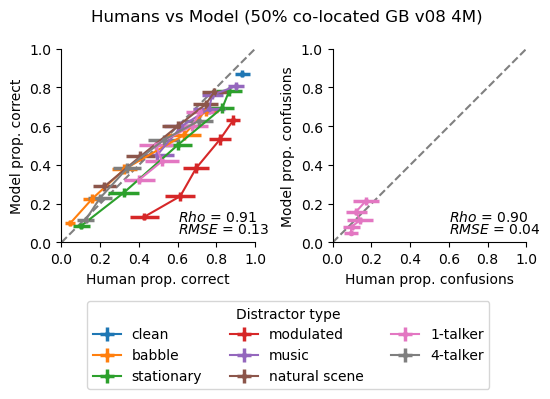

In [52]:
grouped_results = combined_results[~combined_results.background_condition.isin(["catch_trial", 'audioset'])]

hue_order = ['clean', 'babble',  'stationary', 'modulated', 'music', 'natural scene', "1-talker", "4-talker"]
palette = dict(zip(hue_order, sns.color_palette(n_colors= len(hue_order), as_cmap=True)))

x = y = np.linspace(0,1,6)


fontsize = 10

# model_list = ["Binaural CommonVoice", "Binaural Half-CoLocated CV", 'Mono CommonVoice', 'Diotic CommonVoice', 'Mono WordSpeakerNoise']
model_list = grouped_results.group.unique()[1:]

# fig, axs = plt.subplots(2,len(model_list), figsize=((4*len(model_list)),8))
fig, axs = plt.subplots(1,2, figsize=((6*len(model_list)),3))


# for ix, group in enumerate(grouped_results.group.unique()):
# add dashed line to each subplot 
for ax in axs.flat:
    ax.plot(x,y, ls='dashed', color='grey')

human_df = grouped_results[grouped_results.group.str.contains('Participants')]
# get adjusted_confusion data
human_conf_data = human_df[human_df.background_condition ==  "1-talker"]
human_conf_means = human_conf_data["adjusted_confusions"].values
human_conf_errors = human_conf_data["adj_conf_std_error"].values * 2 # 95% CI

for ix, model in enumerate(model_list):
    print(model)
    model_df = grouped_results[grouped_results.group == model]
    # summarize model data
    model_df = model_df.groupby(['snr', 'background_condition']).agg({'accuracy': ['mean', 'sem',], 'confusions':['mean', 'sem'], 
                                                                        'adjusted_accuracy': ['mean', 'sem',], 'adjusted_confusions':['mean', 'sem', 'count']}).reset_index()
    # rename columns
    model_df.columns = ['snr', 'background_condition', 'accuracy', 'acc_std_error', 'confusions', 'conf_std_error', 'adjusted_accuracy', 'adj_acc_std_error', 'adjusted_confusions', 'adj_conf_std_error', 'N']
    

    for condition in hue_order:
        # print(condition)
        # plot acc 
        human_data = human_df[human_df.background_condition == condition]
        human_means = human_data["adjusted_accuracy"].values
        human_errors = human_data["adj_acc_std_error"].values * 2 # 95% CI

        model_data = model_df[model_df.background_condition == condition]
        model_means = model_data["adjusted_accuracy"].values
        model_errors = model_data["adj_acc_std_error"].values * 2 # 95% CI

        axs[0].errorbar(x=human_means, y=model_means, xerr=human_errors, yerr=model_errors, marker='o', linestyle='-', ms=3, elinewidth=2.5, label= condition,
                            color=palette[condition])#, mfc=palette[condition], mec=palette[condition])


    # model adjusted_confusions
    model_conf_data = model_df[model_df.background_condition ==  "1-talker"]
    model_conf_means = model_conf_data["adjusted_confusions"].values
    model_conf_errors = model_conf_data["adj_conf_std_error"].values * 2 # 95% CI 

    axs[1].errorbar(x=human_conf_means, y=model_conf_means, xerr=human_conf_errors, yerr=model_conf_errors, marker='o', linestyle='-', ms=3, elinewidth=2.5, label= "1-talker",
                        color=palette[ "1-talker"])
    
    # Add error annotations 
    # acc errors 
    res = stats.spearmanr(human_df["adjusted_accuracy"].values,  model_df['adjusted_accuracy'].values)
    rho = res.correlation
    axs[0].annotate(f"$Rho$ = {rho:.2f}", (0.6, 0.11), fontsize=fontsize)
    samp_rmse = np.sqrt(np.mean((human_df["adjusted_accuracy"].values - model_df['adjusted_accuracy'].values)**2))
    axs[0].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.6, 0.05), fontsize=fontsize)
    # conf errors
    res = stats.spearmanr(human_conf_means, model_conf_means)
    rho = res.correlation
    axs[1].annotate(f"$Rho$ = {rho:.2f}", (0.6, 0.11), fontsize=fontsize)   # old xy coords ( 0.25, 0.05)
    samp_rmse = np.sqrt(np.mean((human_conf_means - model_conf_means)**2))
    axs[1].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.6, 0.05), fontsize=fontsize) # old xy coords ( 0.25, 0.025)
    # add tiles 
    # axs[0].set_title(model, fontsize=fontsize)
    axs[0].set_xlabel(f"Human prop. correct", fontsize=fontsize)
    axs[1].set_xlabel(f"Human prop. confusions", fontsize=fontsize)

    
# set first row x and y limits to 0 1 and have same tick values 
for ax in axs.flat:
    ax.set_xlim(0,1)
    ax.set_ylim(0,1)
    ax.set_xticks(x)
    ax.set_yticks(y)

# for ax in axs.flat:
#     ax.set_xlim(0,1)
#     ax.set_ylim(0,1)


axs[0].set_ylabel(f"Model prop. correct", fontsize=fontsize)
axs[1].set_ylabel(f"Model prop. confusions", fontsize=fontsize)

# make square 
ratio = 1 
axs[0].set_aspect(ratio, adjustable='box')
axs[1].set_aspect(ratio, adjustable='box')

sns.despine()
lines_labels = [ax.get_legend_handles_labels() for ax in [axs[0]]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
plt.subplots_adjust(wspace=0.4)

fig.legend(lines, hue_order, bbox_transform=fig.transFigure, ncol=3, title='Distractor type',  bbox_to_anchor=(0.85, 0),)
# plt.tight_layout()
# 

plt.suptitle(f"Humans vs Model ({model})", y=0.95)



## Compare adjusted to standard scores

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/matplotlib/axes/_base.py:2475: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/matplotlib/axes/_base.py:2475: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/matplotlib/axes/_base.py:2475: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/matplotlib/axes/_base.py:2475: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/matplotlib/axes/_base.py:2475: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)
/om2/user/imgriff/conda_envs/torch_

Text(0.5, 0.95, 'in-transcript (y-axis) vs single-word (x-axis) scoring')

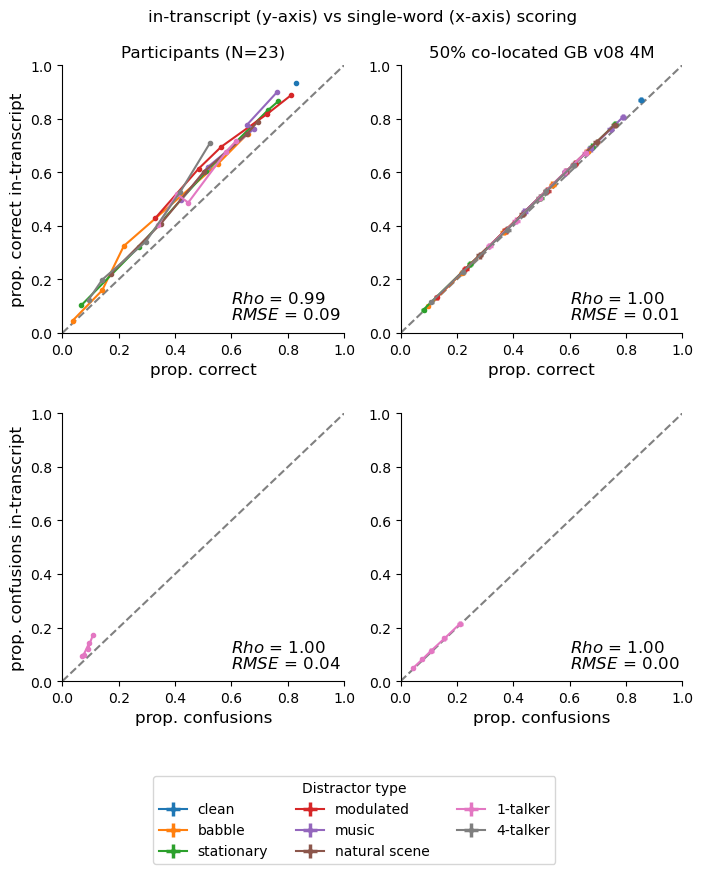

In [53]:
grouped_results = combined_results[~combined_results.background_condition.isin(["catch_trial", 'audioset'])]

hue_order = ['clean', 'babble',  'stationary', 'modulated', 'music', 'natural scene', "1-talker", "4-talker"]
palette = dict(zip(hue_order, sns.color_palette(n_colors= len(hue_order), as_cmap=True)))

x = y = np.linspace(0,1,5)

fontsize = 12
model_list = grouped_results.group.unique()

# model_list = ["Binaural CommonVoice", "Binaural Half-CoLocated CV", 'Mono CommonVoice', 'Diotic CommonVoice', 'Mono WordSpeakerNoise']

n_plots = len(model_list) 
fig, axs = plt.subplots(2,n_plots, figsize=(4*n_plots,8))


# for ix, group in enumerate(grouped_results.group.unique()):
# add dashed line to each subplot 
for ax in axs.flat:
    ax.plot(x,y, ls='dashed', color='grey')

human_df = grouped_results[grouped_results.group == f'Participants (N={N})']
# get adjusted_confusion data
human_conf_data = human_df[human_df.background_condition ==  "1-talker"]
human_conf_means = human_conf_data["adjusted_confusions"].values
human_conf_errors = human_conf_data["adj_conf_std_error"].values

for ix in range(n_plots):
    # if ix == 0:
        # plot_df = grouped_results[grouped_results.group == f'participants (N={N})']
    # else:
    model = model_list[ix]
    plot_df = grouped_results[grouped_results.group == model]
    # summarize model data
    plot_df = plot_df.groupby(['snr', 'background_condition']).agg({'accuracy': ['mean', 'sem',], 'confusions':['mean', 'sem'], 
                                                                        'adjusted_accuracy': ['mean', 'sem',], 'adjusted_confusions':['mean', 'sem', 'count']}).reset_index()
    # rename columns
    plot_df.columns = ['snr', 'background_condition', 'accuracy', 'acc_std_error', 'confusions', 'conf_std_error', 'adjusted_accuracy', 'adj_acc_std_error', 'adjusted_confusions', 'adj_conf_std_error', 'N']

    for condition in hue_order:
        # plot acc 
        data = plot_df[plot_df.background_condition == condition]
        means = data["accuracy"].values
        errors = data["acc_std_error"].values
        adj_means = data["adjusted_accuracy"].values
        adj_errors = data["adj_acc_std_error"].values

        axs[0,ix].errorbar(x=means, y=adj_means, xerr=errors, yerr=adj_errors, marker='o', linestyle='-', ms=3, elinewidth=2.5, label= condition,
                            color=palette[condition])#, mfc=palette[condition], mec=palette[condition])


    # model adjusted_confusions
    conf_data = plot_df[plot_df.background_condition ==  "1-talker"]
    conf_means = conf_data["confusions"].values
    conf_errors = conf_data["conf_std_error"].values
    adj_conf_means = conf_data["adjusted_confusions"].values
    adj_conf_errors = conf_data["adj_conf_std_error"].values

    axs[1,ix].errorbar(x=conf_means, y=adj_conf_means, xerr=conf_errors, yerr=adj_conf_errors, marker='o', linestyle='-', ms=3, elinewidth=2.5, label= "1-talker",
                        color=palette[ "1-talker"])
    
    # Add error annotations 
    # acc errors 
    res = stats.spearmanr(plot_df["accuracy"].values,  plot_df['adjusted_accuracy'].values)
    rho = res.correlation
    axs[0,ix].annotate(f"$Rho$ = {rho:.2f}", (0.6, 0.11), fontsize=fontsize)
    samp_rmse = np.sqrt(np.mean((plot_df["accuracy"].values - plot_df['adjusted_accuracy'].values)**2))
    axs[0,ix].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.6, 0.05), fontsize=fontsize)
    # conf errors
    res = stats.spearmanr(conf_means, adj_conf_means)
    rho = res.correlation
    axs[1,ix].annotate(f"$Rho$ = {rho:.2f}", (0.6, 0.11), fontsize=fontsize)   # old xy coords ( 0.25, 0.05)
    samp_rmse = np.sqrt(np.mean((conf_means - adj_conf_means)**2))
    axs[1,ix].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.6, 0.05), fontsize=fontsize) # old xy coords ( 0.25, 0.025)
    # add tiles 
    axs[0,ix].set_title(model, fontsize=fontsize)
    axs[0,ix].set_xlabel(f"prop. correct", fontsize=fontsize)
    axs[1,ix].set_xlabel(f"prop. confusions", fontsize=fontsize)

    
# set first row x and y limits to 0 1
for ax in axs.flat:
    ax.set_xlim(0,1)
    ax.set_ylim(0,1)

axs[0,0].set_ylabel(f"prop. correct in-transcript", fontsize=fontsize)
axs[1,0].set_ylabel(f"prop. confusions in-transcript", fontsize=fontsize)

sns.despine()
lines_labels = [ax.get_legend_handles_labels() for ax in [axs[0,0]]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
plt.subplots_adjust(hspace=0.3)

fig.legend(lines, hue_order, bbox_transform=fig.transFigure, ncol=3, title='Distractor type',  bbox_to_anchor=(0.75, 0),)
# plt.tight_layout()



plt.suptitle(f"in-transcript (y-axis) vs single-word (x-axis) scoring", y=0.95)



## More specific line plots

Text(0.5, 1.05, 'Using Kell/Saddler conditions: middle word accuracy')

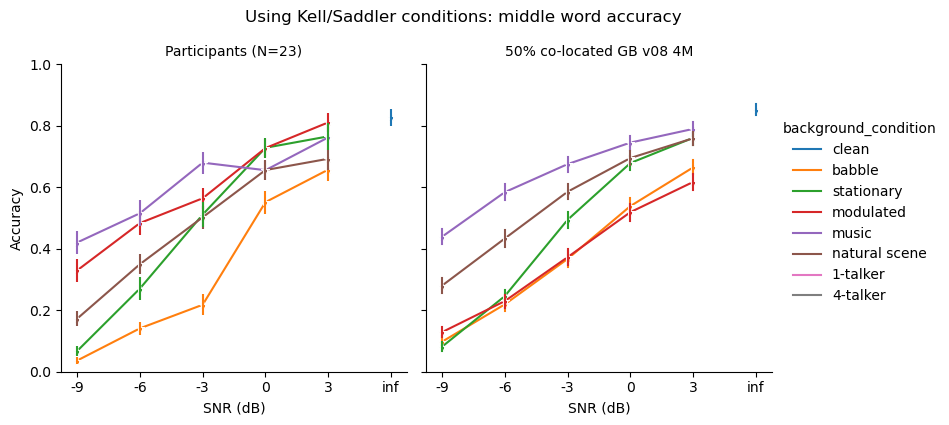

In [54]:
# to_plot = combined[(combined.condition!='audioset') & (combined.snr > -12)]
to_plot = combined_results[~combined_results.background_condition.isin(["catch_trial", "1-talker", "4-talker", "audioset"])]
# palette = dict(zip(to_plot.background_condition.unique(), sns.color_palette(n_colors= len(to_plot.background_condition.unique()), as_cmap=True)))

# add markers to relplot
# plt.figure(figsize=(2,2))
# add markers to relplot
g = sns.relplot(data=to_plot, x='snr', y='accuracy', col='group', hue='background_condition', hue_order=hue_order,
                # style='model', style_order=['human', "attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor"],
                err_style='bars', errorbar=('ci', 95),
                  kind='line', marker='*', palette=palette, height=4, aspect=1)
# g.map(plt.errorbar, "snr", "accuracy", "std_error", marker=None, ls='none')

# set labels 
g.set_axis_labels("SNR (dB)", "Accuracy")
g.set_titles("{col_name}")

# iterate through each facet of the facetgrid
for model, ax in g.axes_dict.items():
    # select the data for the facet
    data = to_plot[to_plot['group'].eq(model)]
    # select the data for each hue group
    for group, selected in data.groupby('background_condition'):
        # plot the errorbar with the correct color for each group 
        ax.errorbar(data=selected, x="snr", y="accuracy", yerr="acc_std_error", color=palette[group], marker=None, ls='none' )

x_tick_locs = to_plot.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)
plt.ylim(0,1)


plt.suptitle(f"Using Kell/Saddler conditions: middle word accuracy", y=1.05)

# plt.tight_layout()

Text(0.5, 1.05, 'Using Kell/Saddler conditions: in-transcript accuracy')

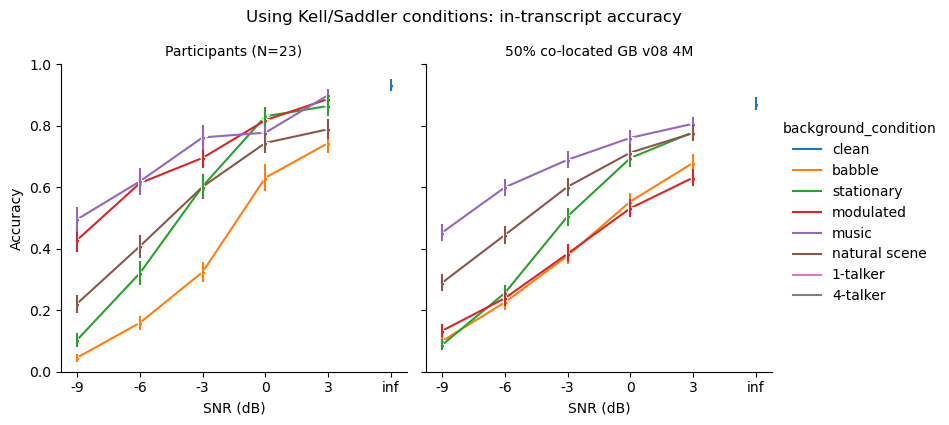

In [55]:
# to_plot = combined[(combined.condition!='audioset') & (combined.snr > -12)]
to_plot = combined_results[~combined_results.background_condition.isin(["catch_trial", "1-talker", "4-talker", "audioset"])]
# palette = dict(zip(to_plot.background_condition.unique(), sns.color_palette(n_colors= len(to_plot.background_condition.unique()), as_cmap=True)))

# add markers to relplot
# plt.figure(figsize=(2,2))
# add markers to relplot
g = sns.relplot(data=to_plot, x='snr', y='adjusted_accuracy', col='group', hue='background_condition', hue_order=hue_order,
                # style='model', style_order=['human', "attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor"],
                err_style='bars', errorbar=('ci', 95),
                  kind='line', marker='*', palette=palette, height=4, aspect=1)
# g.map(plt.errorbar, "snr", "accuracy", "std_error", marker=None, ls='none')

# set labels 
g.set_axis_labels("SNR (dB)", "Accuracy")
g.set_titles("{col_name}")

# iterate through each facet of the facetgrid
for model, ax in g.axes_dict.items():
    # select the data for the facet
    data = to_plot[to_plot['group'].eq(model)]
    # select the data for each hue group
    for group, selected in data.groupby('background_condition'):
        # plot the errorbar with the correct color for each group 
        ax.errorbar(data=selected, x="snr", y="adjusted_accuracy", yerr="adj_acc_std_error", color=palette[group], marker=None, ls='none' )

x_tick_locs = to_plot.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)
plt.ylim(0,1)


plt.suptitle(f"Using Kell/Saddler conditions: in-transcript accuracy", y=1.05)

# plt.tight_layout()

Text(0.5, 1.05, 'Conditions used in TIMIT experiment: middle word accuracy')

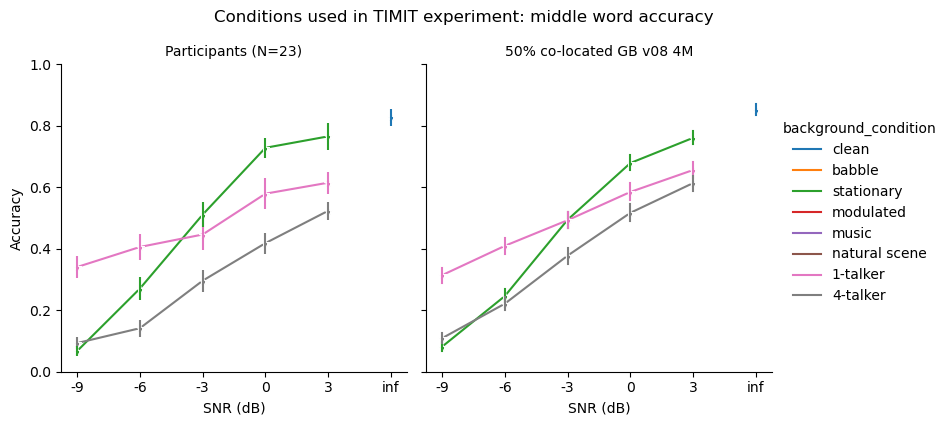

In [56]:

# to_plot = combined[(combined.condition!='audioset') & (combined.snr > -12)]
to_plot_list = ["1-talker", "4-talker", "clean", "babble"]
to_plot = combined_results[combined_results.background_condition.isin(["1-talker", "4-talker", "clean", "stationary"])]
# palette = dict(zip(to_plot.background_condition.unique(), sns.color_palette(n_colors= len(to_plot.background_condition.unique()), as_cmap=True)))

# add markers to relplot
# add markers to relplot
g = sns.relplot(data=to_plot, x='snr', y='accuracy', col='group', hue='background_condition', hue_order=hue_order,
                # style='model', style_order=['human', "attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor"],
                  kind='line', marker='*', palette=palette, height=4, aspect=1, err_style='bars', errorbar=('ci', 95))
# g.map(plt.errorbar, "snr", "accuracy", "std_error", marker=None, ls='none')

# set labels 
g.set_axis_labels("SNR (dB)", "Accuracy")
g.set_titles("{col_name}")

# iterate through each facet of the facetgrid
for model, ax in g.axes_dict.items():
    # skip the model facet - we bootstrap above
    if model == 'model':
        continue
    # select the data for the facet
    data = to_plot[to_plot['group'].eq(model)]
    # select the data for each hue group
    for group, selected in data.groupby('background_condition'):
        # plot the errorbar with the correct color for each group 
        ax.errorbar(data=selected, x="snr", y="accuracy", yerr="acc_std_error", color=palette[group], marker=None, ls='none' )

x_tick_locs = to_plot.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)
plt.ylim(0,1)


plt.suptitle(f"Conditions used in TIMIT experiment: middle word accuracy", y=1.05)


# plt.tight_layout()

Text(0.5, 1.05, 'Conditions used in TIMIT experiment: in-transcript accuracy')

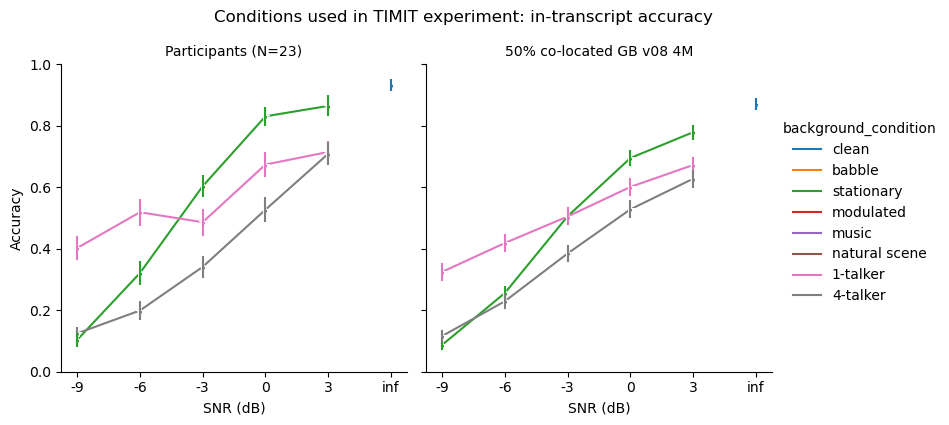

In [57]:
# part_summary_df.rename(columns={'mean': 'accuracy', 'condition': "
# to_plot = combined[(combined.condition!='audioset') & (combined.snr > -12)]
to_plot_list = ["1-talker", "4-talker", "clean", "babble"]
to_plot = combined_results[combined_results.background_condition.isin(["1-talker", "4-talker", "clean", "stationary"])]
# palette = dict(zip(to_plot.background_condition.unique(), sns.color_palette(n_colors= len(to_plot.background_condition.unique()), as_cmap=True)))

# add markers to relplot
# add markers to relplot
g = sns.relplot(data=to_plot, x='snr', y='adjusted_accuracy', col='group', hue='background_condition', hue_order=hue_order,
                # style='model', style_order=['human', "attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor"],
                  kind='line', marker='*', palette=palette, height=4, aspect=1, err_style='bars', errorbar=('ci', 95))
# g.map(plt.errorbar, "snr", "accuracy", "std_error", marker=None, ls='none')

# set labels 
g.set_axis_labels("SNR (dB)", "Accuracy")
g.set_titles("{col_name}")

# iterate through each facet of the facetgrid
for model, ax in g.axes_dict.items():
    # skip the model facet - we bootstrap above
    if model == 'model':
        continue
    # select the data for the facet
    data = to_plot[to_plot['group'].eq(model)]
    # select the data for each hue group
    for group, selected in data.groupby('background_condition'):
        # plot the errorbar with the correct color for each group 
        ax.errorbar(data=selected, x="snr", y="adjusted_accuracy", yerr="adj_acc_std_error", color=palette[group], marker=None, ls='none' )

x_tick_locs = to_plot.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)
plt.ylim(0,1)


plt.suptitle(f"Conditions used in TIMIT experiment: in-transcript accuracy", y=1.05)


# plt.tight_layout()background_condition"}, inplace=True)

In [58]:
part_summary_df.snr.unique()

array([-9, -6, -3,  0,  3,  6])

## Move on to f0 / gender analysis 

In [59]:
all_model_f0_results.head()


,pred_word_int,true_word_int,accuracy,model,background_condition,snr,test_index,word,word_int,gender,...,distractor_transcripts,group,pred_word,true_word,confusions,adjusted_accuracy,adjusted_confusions,gender_cond,abs_f0_diff,percent_f0_diff
0,703,703,1,word_task_half_co_loc_v08_gender_bal_4M_sanity,clean,inf,0,these,703,female,...,"[made, from, either, dna, or]",50% co-located GB v08 4M,these,these,0,1,0,clean,7.836792,1.043174
1,703,703,1,word_task_half_co_loc_v08_gender_bal_4M_sanity,clean,inf,1,these,703,female,...,"[in, one thousand, nine hundred and forty, sev...",50% co-located GB v08 4M,these,these,0,1,0,clean,51.455109,0.716530
2,623,623,1,word_task_half_co_loc_v08_gender_bal_4M_sanity,clean,inf,2,simply,623,female,...,"[of, the, core, rule, books, were, slightly, r...",50% co-located GB v08 4M,simply,simply,0,1,0,clean,10.621445,1.057183
3,623,623,1,word_task_half_co_loc_v08_gender_bal_4M_sanity,clean,inf,3,simply,623,female,...,"[philadelphia, created, in, seventeen]",50% co-located GB v08 4M,simply,simply,0,1,0,clean,78.503159,0.577360
4,175,175,1,word_task_half_co_loc_v08_gender_bal_4M_sanity,clean,inf,4,death,175,male,...,"[this, was, a, then, unknown, fault]",50% co-located GB v08 4M,death,death,0,1,0,clean,132.301056,2.467151


In [60]:
f0_analysis_df.columns

Index(['time_elapsed', 'internal_node_id', 'output_filename', 'id_random',
       'id_study', 'id_subject', 'id_session', 'id_version', 'hc_passed', 'rt',
       'response', 'stimulus', 'response_str', 'correct_response', 'correct',
       'n_correct', 'n_incorrect', 'snr', 'background_condition', 'accuracy',
       'base_str', 'target_gender', 'target_f0', 'distractor_f0',
       'distractor_gender', 'distractor_word', 'target_transcript',
       'distractor_transcript', 'confusions', 'adjusted_accuracy',
       'adjusted_confusions', 'gender_cond', 'abs_f0_diff', 'percent_f0_diff'],
      dtype='object')

In [61]:
f0_analysis_df.snr.unique()

array([3, -3, -6, 0, 'inf', -9], dtype=object)

In [68]:
# # combine f0_analysis_df and model_f0_df keeping only columns in both
# model_f0_df['id_subject'] = 'model'
# model_f0_df['group'] = 'model'
all_model_f0_results['id_subject'] = all_model_f0_results['group']
f0_analysis_df['group'] = 'participants'

f0_analysis_df.reset_index(inplace=True, drop=True)
all_model_f0_results.reset_index(inplace=True, drop=True)
combined_f0_df = pd.concat([f0_analysis_df, all_model_f0_results],axis=0, ignore_index=True)

# combined_f0_df = combined_f0_df[combined_f0_df.background_condition == '1-talker']
combined_f0_df.loc[combined_f0_df.snr == "inf", 'snr'] = 6
combined_f0_df.snr = combined_f0_df.snr.astype('int')
combined_f0_df = combined_f0_df[combined_f0_df.snr > -12]

In [69]:
all_model_f0_results.loc[all_model_f0_results.abs_f0_diff > 200, ['target_f0', 'distractor_f0']]

,target_f0,distractor_f0


In [70]:
# drop rows with nan target f0
combined_f0_df.dropna(subset=['snr','abs_f0_diff'], inplace=True)


In [71]:
combined_f0_df['correct_str'] = combined_f0_df['accuracy'].replace({0: "Miss", 1:"Hit"})

In [72]:
combined_f0_df['abs_f0_diff'] = combined_f0_df['abs_f0_diff'].astype('float')
combined_f0_df['percent_f0_diff'] = (combined_f0_df.distractor_f0.values / combined_f0_df.target_f0.values).astype('float')


participants
50% co-located GB v08 4M


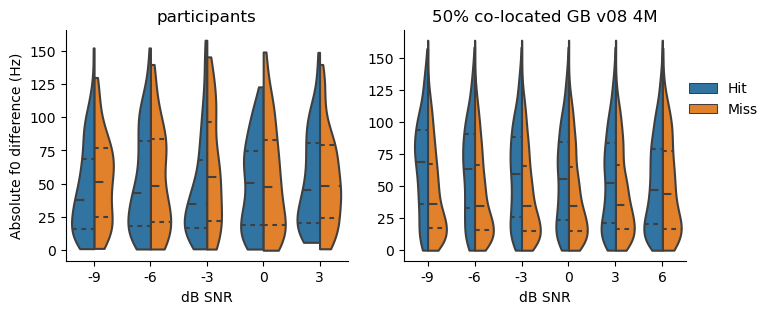

In [73]:
# g = sns.relplot(data=f0_analysis_df, x='f0_diff', y='snr', hue='accuracy',  kind='scatter')
# sns.violinplot(data=f0_analysis_df, x="snr", y="f0_diff", hue="accuracy", split=True, gap=.5, inner="quart")
n_models = combined_f0_df.group.nunique()
fig, axes = plt.subplots(1,combined_f0_df.group.nunique(),figsize=(4 * n_models,3))

# need to fix, for now, toss bad examples 
combined_f0_df.loc[combined_f0_df.abs_f0_diff > 200, 'abs_f0_diff'] = np.nan

fontsize=10
for ix, group_name in enumerate(combined_f0_df.group.unique()):
    print(group_name)
    ax = sns.violinplot(data=combined_f0_df[combined_f0_df.group == group_name], x="snr", y="abs_f0_diff", cut=0, 
                        hue="correct_str", split=True, gap=.5, inner="quart", ax=axes[ix])

    ax.set_title(group_name)
    if ix < n_models - 1:
        ax.get_legend().remove()
    if ix == 0:
        ax.set_ylabel('Absolute f0 difference (Hz)', fontsize=fontsize)
    elif ix > 0:
        ax.set_ylabel('')
    ax.set_xlabel('dB SNR', fontsize=fontsize)


# if ix == 2:
sns.move_legend(ax, title='',
                loc="center right", bbox_to_anchor=(1.3, .7),
                frameon=False, title_size=fontsize, fontsize=fontsize)
sns.despine()
# ax1.set_ylabel('% f0 difference', fontsize=fontsize)


In [74]:
# pd.cut(to_plot['abs_f0_diff'], bins=5, labels=[0, 25, 50, 100, 150])

In [75]:
to_plot.adjusted_confusions

0        0.171498
1             NaN
6             NaN
7        0.121256
8             NaN
           ...   
60834    0.000000
60835    0.000000
60836    0.000000
60837    0.000000
60838    0.000000
Name: adjusted_confusions, Length: 22640, dtype: float64

[1.10077058e-01 3.16454638e+01 6.31808505e+01 9.47162372e+01
 1.26251624e+02 1.57787011e+02]


/tmp/ipykernel_2435087/809470209.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot['f0_diff_bin'] = pd.cut(to_plot['abs_f0_diff'], bins=bins, labels=bins[:-1])


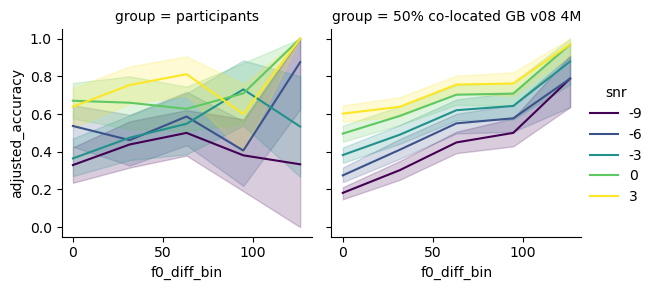

In [78]:
## For f0 plots 
n_models = combined_f0_df.group.nunique()
to_plot = combined_f0_df[combined_f0_df.snr.isin(np.arange(-9,6))]
# histogram abs_f0_diff into 5 bins 
n_bins = 6

min_f0_diff = to_plot[(to_plot.abs_f0_diff > 0) & (to_plot.group == 'participants')].abs_f0_diff.min()
max_f0_diff = to_plot[(to_plot.group == 'participants')].abs_f0_diff.max()
bins = np.linspace(min_f0_diff, max_f0_diff, n_bins)
print(bins)
to_plot['f0_diff_bin'] = pd.cut(to_plot['abs_f0_diff'], bins=bins, labels=bins[:-1])
# to_plot = to_plot.groupby(['id_subject',  'group', 'snr', 'f0_diff_bin']).agg({'adjusted_accuracy':np.nanmean, 'adjusted_confusions':np.nanmean}).reset_index()

to_plot
sns.relplot(data=to_plot, x='f0_diff_bin', y='adjusted_accuracy', col='group', hue='snr', kind='line', palette='viridis', height=3, aspect=1)


In [79]:
# plot accuracy vs f0 difference with lines as snr and columns for group
n_models = combined_f0_df.group.nunique()
to_plot = combined_f0_df[combined_f0_df.snr.isin(np.arange(-9,4,3))]
# histogram abs_f0_diff into 5 bins 
n_bins = 10
min_f0_diff = combined_f0_df[combined_f0_df.abs_f0_diff > 10].abs_f0_diff.min()
max_f0_diff = combined_f0_df.abs_f0_diff.max()
bins = np.linspace(min_f0_diff, max_f0_diff, n_bins)
print(bins)
to_plot['abs_f0_diff_bin'] = pd.cut(to_plot['abs_f0_diff'], bins=n_bins, labels=bins)



[ 10.10890198  27.1934238   44.27794562  61.36246745  78.44698927
  95.53151109 112.61603292 129.70055474 146.78507657 163.86959839]


/tmp/ipykernel_2435087/3267333525.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot['abs_f0_diff_bin'] = pd.cut(to_plot['abs_f0_diff'], bins=n_bins, labels=bins)


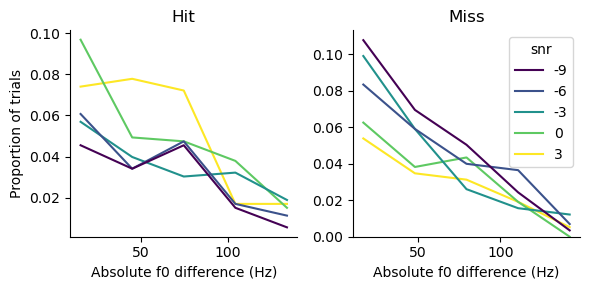

In [80]:
# g = sns.relplot(data=f0_analysis_df, x='f0_diff', y='snr', hue='accuracy',  kind='scatter')
# sns.violinplot(data=f0_analysis_df, x="snr", y="f0_diff", hue="accuracy", split=True, gap=.5, inner="quart")
n_models = combined_f0_df.group.nunique()
snrs = sorted(combined_f0_df.snr.unique())[1:-1]

fig, axes = plt.subplots(1, 2, figsize=( 6, 3))

# set colors
# palette = {'Hit':'tab:blue', 'Miss':'tab:orange'} 
# colors = sns.color_palette("tab10", n_colors=n_models)
# palette = dict(zip(combined_f0_df.group.unique(), colors))

fontsize=10
for ix, cond_name in enumerate(['Hit', 'Miss']):
    ## Add v line at 1 
    # axes[ix,jx].vlines(1,0, 0.05, colors='k', linestyle='dashed', alpha=0.5)
    ax = sns.histplot(data=combined_f0_df[(combined_f0_df.correct_str == cond_name) & (combined_f0_df.group == 'participants')],
                    x="abs_f0_diff", 
                    stat='proportion',
                    bins=5,
                    shrink=.8,
                    element="poly",
                    fill=False,
                    hue="snr",
                    palette = 'viridis',
                    ax=axes[ix])

    ax.set_title(f"{cond_name}")
    if ix == 0:
        ax.get_legend().remove()
    if ix == 0:
        ax.set_ylabel('Proportion of trials', fontsize=fontsize)
    elif ix > 0:
        ax.set_ylabel('')
    ax.set_xlabel('Absolute f0 difference (Hz)', fontsize=fontsize)
    # ax.set_ylim(0,0.1)
    # ax.set_xlim(0,150)


# if ix == 2:
# sns.move_legend(ax, title='',
#                 loc="center right", bbox_to_anchor=(2.1, .7),
#                 frameon=False, title_size=fontsize, fontsize=fontsize)
sns.despine()
plt.tight_layout()
# ax1.set_ylabel('% f0 difference', fontsize=fontsize)


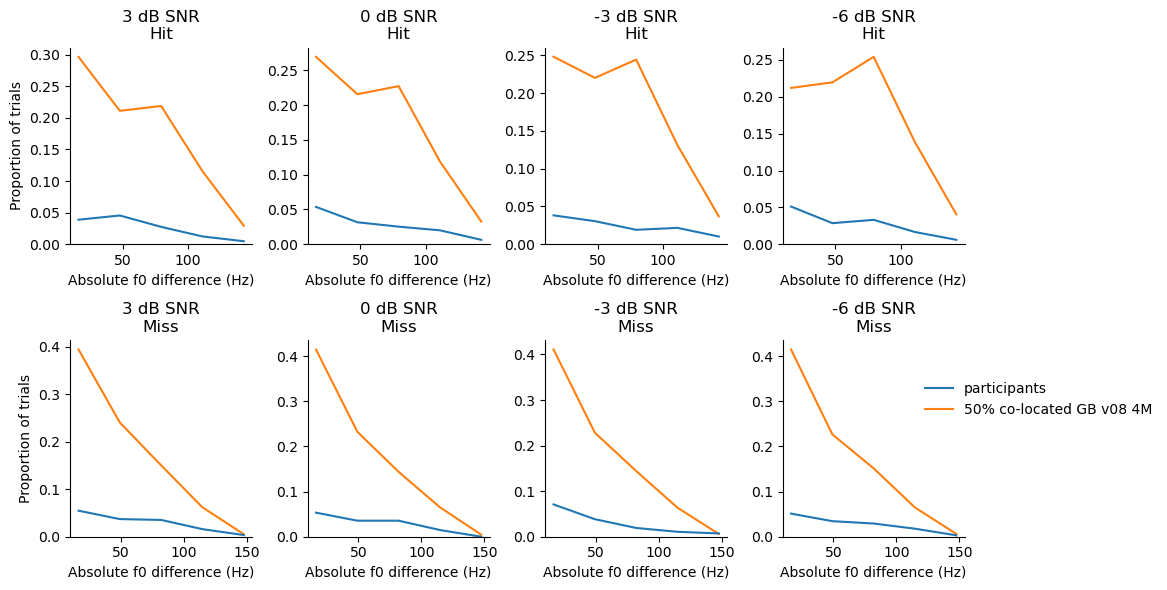

In [81]:
# g = sns.relplot(data=f0_analysis_df, x='f0_diff', y='snr', hue='accuracy',  kind='scatter')
# sns.violinplot(data=f0_analysis_df, x="snr", y="f0_diff", hue="accuracy", split=True, gap=.5, inner="quart")
n_models = combined_f0_df.group.nunique()
snrs = sorted(combined_f0_df.snr.unique())[1:-1]

fig, axes = plt.subplots(2, len(snrs), figsize=( 3 * len(snrs), 6))

# set colors
# palette = {'Hit':'tab:blue', 'Miss':'tab:orange'} 
colors = sns.color_palette("tab10", n_colors=n_models)
palette = dict(zip(combined_f0_df.group.unique(), colors))

fontsize=10
for ix, cond_name in enumerate(['Hit', 'Miss']):
    for jx, snr_val in enumerate(snrs[::-1]):
        ## Add v line at 1 
        # axes[ix,jx].vlines(1,0, 0.05, colors='k', linestyle='dashed', alpha=0.5)
        ax = sns.histplot(data=combined_f0_df[(combined_f0_df.correct_str == cond_name) & (combined_f0_df.snr == snr_val)],
                        x="abs_f0_diff", 
                        stat='proportion',
                        bins=5,
                        shrink=.8,
                        element="poly",
                        fill=False,
                        hue="group",
                        palette = palette,
                        ax=axes[ix, jx])

        ax.set_title(f"{snr_val} dB SNR\n{cond_name}")
        if jx < len(snrs) - 1 or ix == 0:
            ax.get_legend().remove()
        if jx == 0:
            ax.set_ylabel('Proportion of trials', fontsize=fontsize)
        elif jx > 0:
            ax.set_ylabel('')
        ax.set_xlabel('Absolute f0 difference (Hz)', fontsize=fontsize)
        # ax.set_ylim(0,0.1)
        # ax.set_xlim(0,150)


# if ix == 2:
sns.move_legend(ax, title='',
                loc="center right", bbox_to_anchor=(2.1, .7),
                frameon=False, title_size=fontsize, fontsize=fontsize)
sns.despine()
plt.tight_layout()
# ax1.set_ylabel('% f0 difference', fontsize=fontsize)


KeyError: '50% co-located v07'

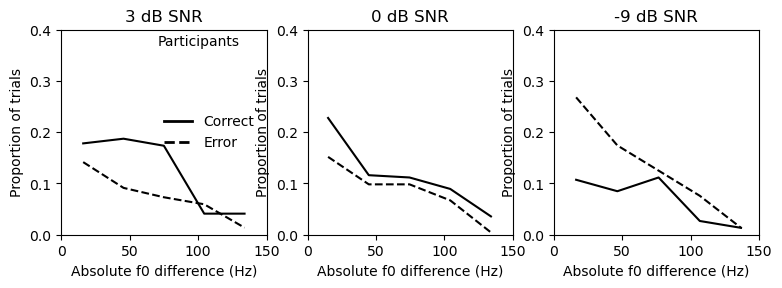

In [82]:
import matplotlib as mpl
to_plot = combined_f0_df[combined_f0_df.group.isin(['participants', '50% co-located v07', 'Baseline CNN'])]
snrs = sorted(combined_f0_df.snr.unique())[::-1]
snrs = [3, 0, -9]
fontsize=10
# sns.set_context('talk')

# Set the line styles for different groups in correct_str
line_styles = {'Hit': '-', 'Miss': '--'}

# Create subplots for each SNR value
fig, axes = plt.subplots(1, len(snrs), figsize=(3 * len(snrs), 3))
# make aspect square

# get colors
colors = sns.color_palette("viridis", n_colors=3)
palette = dict(zip(to_plot.group.unique(), colors))
palette['participants'] = 'k'

# Iterate over each SNR value
for i, snr in enumerate(snrs):
    # Get the data for the current SNR value
    data = to_plot[to_plot['snr'] == snr]
    
    # Create a histogram for each model
    for model in data['group'].unique():
        model_data = data[data['group'] == model]
        
        # Create a histogram with different line styles for different groups in correct_str
        hst = sns.histplot(data=model_data, x='abs_f0_diff', hue='correct_str', 
                    hue_order = ['Hit', 'Miss'], # sets line style order below
                    element='poly',
                    bins = 5,
                    fill=False,
                    stat='proportion',
                    palette=[palette[model]] * 2 ,
                    legend=False,
                    #  linestyle=list(line_styles.values()),
                     ax=axes[i])
        for ix, line in enumerate(hst.lines):
            if ix % 2 == 0:
                line.set_linestyle('--')
            else: # ix == 1:
                line.set_linestyle('-')
    
    # Set the title and labels for the subplot
    axes[i].set_title(f"{snr} dB SNR")
    axes[i].set_xlabel('Absolute f0 difference (Hz)')
    axes[i].set_ylabel('Proportion of trials')
    axes[i].set_ylim(0,0.4)
    axes[i].set_xlim(0,150)
    # change line styles per line item 

## Set aspect ratios so pannels are square
ratio = 1  
for ax in axes:
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    # for axis in ['bottom','left']:
    #     ax.spines[axis].set_linewidth(1.5)


# Add a legend with colors and style 
# Create a custom legend for the different line styles
custom_lines = [mpl.lines.Line2D([0], [0], color='k', linestyle='-', lw=2),
                mpl.lines.Line2D([0], [0], color='k', linestyle='--', lw=2)]
# # Create a custom legend for the different group names as colored text 
axes[0].legend(custom_lines, ['Correct', 'Error'], loc='center right', fontsize=fontsize, frameon=False)
## Add text to state model colors 
axes[0].text(70, 0.37, 'Participants', color='k', fontsize=fontsize)
axes[0].text(70, 0.3, 'Feature-based\nattention model', color=palette['50% co-located v07'], fontsize=fontsize)
axes[0].text(70, 0.26, 'Baseline CNN', color=palette['Baseline CNN'], fontsize=fontsize)

# Adjust the layout
sns.despine()
# plt.tight_layout()
# adjust w space 
plt.subplots_adjust(wspace=0.4)

participants
50% co-located GB v08 4M


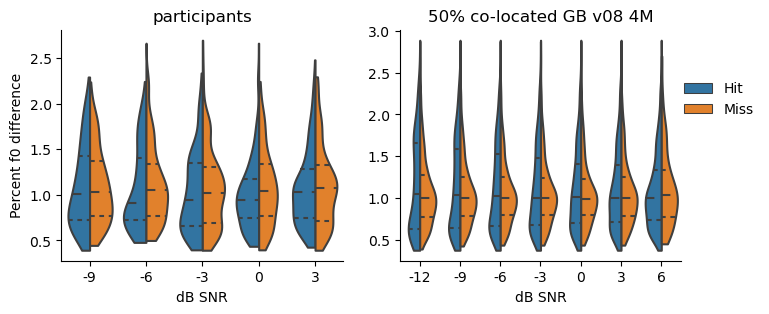

In [ ]:
# g = sns.relplot(data=f0_analysis_df, x='f0_diff', y='snr', hue='accuracy',  kind='scatter')
# sns.violinplot(data=f0_analysis_df, x="snr", y="f0_diff", hue="accuracy", split=True, gap=.5, inner="quart")
n_models = combined_f0_df.group.nunique()
fig, axes = plt.subplots(1,combined_f0_df.group.nunique(),figsize=(4 * n_models,3))

fontsize=10
for ix, group_name in enumerate(combined_f0_df.group.unique()):
    print(group_name)
    ax = sns.violinplot(data=combined_f0_df[combined_f0_df.group == group_name], x="snr", y="percent_f0_diff", cut=0, 
                        hue="correct_str", split=True, gap=.5, inner="quart", ax=axes[ix])

    ax.set_title(group_name)
    if ix < n_models - 1:
        ax.get_legend().remove()
    if ix == 0:
        ax.set_ylabel('Percent f0 difference', fontsize=fontsize)
    elif ix > 0:
        ax.set_ylabel('')
    ax.set_xlabel('dB SNR', fontsize=fontsize)


# if ix == 2:
sns.move_legend(ax, title='',
                loc="center right", bbox_to_anchor=(1.3, .7),
                frameon=False, title_size=fontsize, fontsize=fontsize)
sns.despine()
# ax1.set_ylabel('% f0 difference', fontsize=fontsize)


In [ ]:
combined_f0_df.group.unique()

array(['participants', '50% co-located GB v08 4M'], dtype=object)

[0.5        0.62996052 0.79370053 1.         1.25992105 1.58740105
 2.        ]


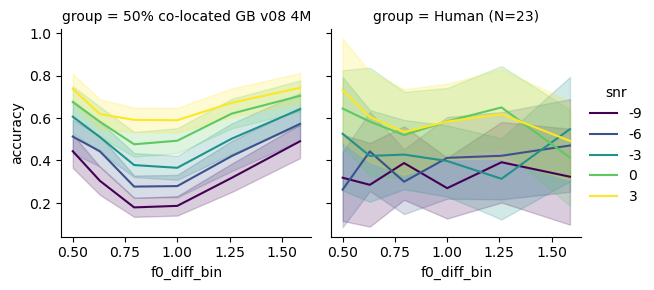

In [83]:
## Same but with percent f0 difference

## For f0 plots 
n_models = combined_f0_df.group.nunique()
to_plot = combined_f0_df[combined_f0_df.snr.isin(np.arange(-9,6))].copy()
# histogram percent_f0_diff into 5 bins 
n_bins = 7

# min_f0_diff = to_plot[(to_plot.percent_f0_diff > 5) & (to_plot.group == 'participants')].percent_f0_diff.min()
# max_f0_diff = to_plot[(to_plot.group == 'participants')].percent_f0_diff.max()
bins = np.geomspace(0.5, 2, n_bins)
# bins=[0,5,10,25,50,100]
print(bins)
to_plot['f0_diff_bin'] = pd.cut(to_plot['percent_f0_diff'], bins=bins, labels=bins[:-1], right=False)
# to_plot['f0_diff_bin'] = pd.qcut(to_plot['percent_f0_diff'], q=5, labels=['large low', 'small low', 'same', 'small up', 'large up'])

to_plot_model = to_plot[to_plot.group != f'participants']
to_plot_human = to_plot[to_plot.group == f'participants']

to_plot_human = to_plot_human.groupby(['id_subject', 'snr', 'f0_diff_bin']).agg({'accuracy':np.nanmean, 'confusions':np.nanmean}).reset_index()
to_plot_human['group'] = f'Human (N={N})'

to_plot = pd.concat([to_plot_model, to_plot_human], axis=0, ignore_index=True)
sns.relplot(data=to_plot, x='f0_diff_bin', y='accuracy', col='group',
            errorbar=('se', 2),
            hue='snr', kind='line', palette='viridis', height=3, aspect=1)


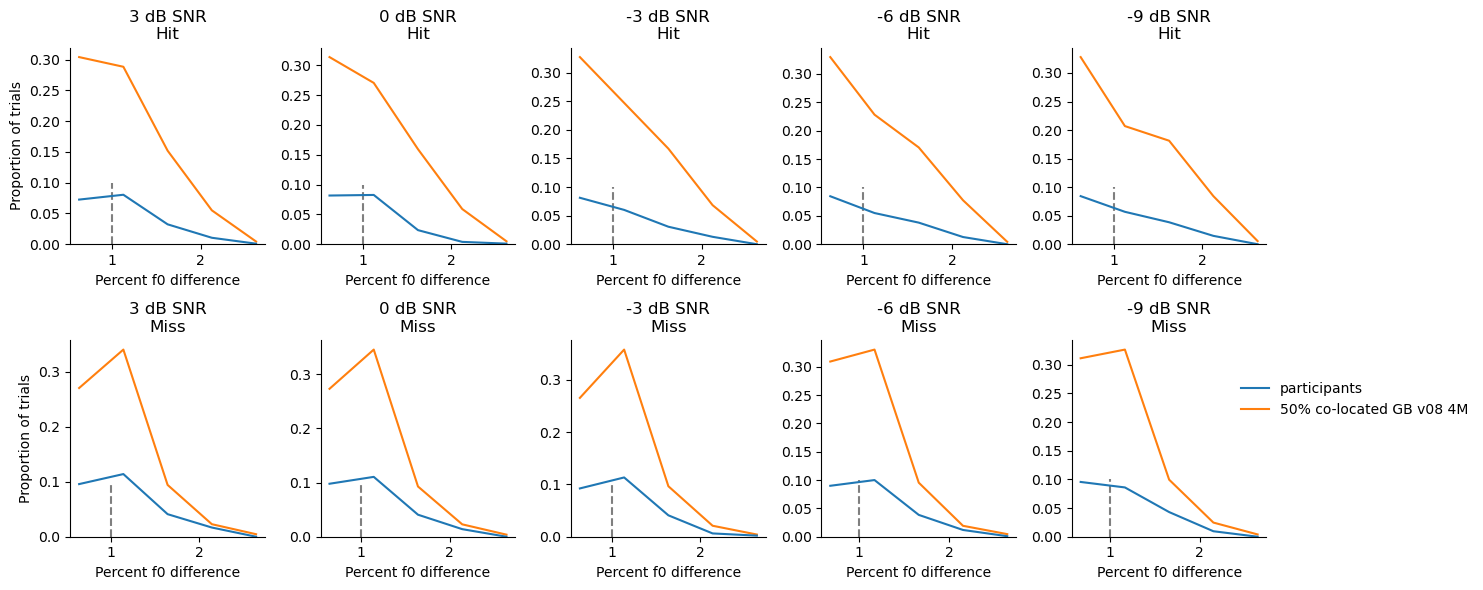

In [ ]:
# g = sns.relplot(data=f0_analysis_df, x='f0_diff', y='snr', hue='accuracy',  kind='scatter')
# sns.violinplot(data=f0_analysis_df, x="snr", y="f0_diff", hue="accuracy", split=True, gap=.5, inner="quart")
n_models = combined_f0_df.group.nunique()
snrs = sorted(combined_f0_df.snr.unique())[1:-1]

fig, axes = plt.subplots(2, len(snrs), figsize=( 3 * len(snrs), 6))

# set colors
# palette = {'Hit':'tab:blue', 'Miss':'tab:orange'} 

fontsize=10
for ix, cond_name in enumerate(['Hit', 'Miss']):
    for jx, snr_val in enumerate(snrs[::-1]):
        ## Add v line at 1 
        axes[ix,jx].vlines(1,0, 0.1, colors='k', linestyle='dashed', alpha=0.5)
        ax = sns.histplot(data=combined_f0_df[(combined_f0_df.correct_str == cond_name) & (combined_f0_df.snr == snr_val)],
                        x="percent_f0_diff", 
                        stat='proportion',
                        bins=5,
                        shrink=.8,
                        element="poly",
                        fill=False,
                        hue="group",
                        ax=axes[ix, jx])

        ax.set_title(f"{snr_val} dB SNR\n{cond_name}")
        if jx < len(snrs) - 1 or ix == 0:
            ax.get_legend().remove()
        if jx == 0:
            ax.set_ylabel('Proportion of trials', fontsize=fontsize)
        elif jx > 0:
            ax.set_ylabel('')
        ax.set_xlabel('Percent f0 difference', fontsize=fontsize)
#         ax.set_ylim(0,0.1)
        # set xticks 
        # ax.set_xticks(np.linspace(0.5,2.5,5))
        # ax.set_xlim(0.4,2.6)

# if ix == 2:
sns.move_legend(ax, title='',
                loc="center right", bbox_to_anchor=(2.1, .7),
                frameon=False, title_size=fontsize, fontsize=fontsize)
sns.despine()
plt.tight_layout()
# ax1.set_ylabel('% f0 difference', fontsize=fontsize)


In [75]:
n_models, snrs


(2, [3, 0, -9])

In [76]:
snrs[::-1]

[-9, 0, 3]

In [77]:
# # g = sns.relplot(data=f0_analysis_df, x='f0_diff', y='snr', hue='accuracy',  kind='scatter')
# # sns.violinplot(data=f0_analysis_df, x="snr", y="f0_diff", hue="accuracy", split=True, gap=.5, inner="quart")
# n_models = combined_f0_df.group.nunique()
# snrs = combined_f0_df.snr.unique()
# snrs.sort()
# fig, axes = plt.subplots(len(snrs), n_models, figsize=(4 * len(snrs), 3 * n_models))

# # set colors
# palette = {'Hit':'tab:blue', 'Miss':'tab:orange'} 

# fontsize=10
# for ix, group_name in enumerate(combined_f0_df.group.unique()):
#     print(group_name)
#     for jx, snr_val in enumerate(snrs[::-1]):
#         ax = sns.histplot(data=combined_f0_df[(combined_f0_df.group == group_name) & (combined_f0_df.snr == snr_val)],
#                         x="percent_f0_diff", 
#                         stat='proportion',
#                         palette=palette,
#                         multiple="dodge", shrink=.8,
#                         hue="correct_str", ax=axes[jx, ix])

#         ax.set_title(f"{snr_val} dB SNR\n{group_name}")
#         if ix < n_models - 1:
#             ax.get_legend().remove()
#         if ix == 0:
#             ax.set_ylabel('Proportion of trials', fontsize=fontsize)
#         elif ix > 0:
#             ax.set_ylabel('')
#     ax.set_xlabel('Percent f0 difference', fontsize=fontsize)


# # if ix == 2:
# sns.move_legend(ax, title='',
#                 loc="center right", bbox_to_anchor=(1.3, .7),
#                 frameon=False, title_size=fontsize, fontsize=fontsize)
# sns.despine()
# plt.tight_layout()
# # ax1.set_ylabel('% f0 difference', fontsize=fontsize)


### Look at f0 ratio

In [84]:
def get_f0_ratio(target_f0, distractor_f0):
    return max(target_f0, distractor_f0) / min(target_f0, distractor_f0)

combined_f0_df['f0_ratio'] = combined_f0_df.apply(lambda x: get_f0_ratio(x.target_f0, x.distractor_f0), axis=1)

In [85]:
combined_f0_df['f0_ratio'].max()

2.8881481381201395

[1.   1.25 1.5  1.75 2.   2.25]


/tmp/ipykernel_2435087/1859459004.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot_model['group'] = 'Model'


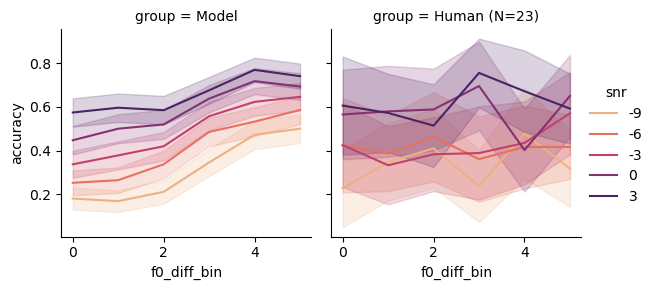

In [86]:
## Same but with percent f0 difference

## For f0 plots 
n_models = combined_f0_df.group.nunique()
to_plot = combined_f0_df[combined_f0_df.snr.isin(np.arange(-9,6))].copy()
# histogram percent_f0_diff into 5 bins 
n_bins = 6

bins = np.linspace(1, 2.25, n_bins)
# bins=[0,5,10,25,50,100]
print(bins)
# to_plot['f0_diff_bin'] = pd.cut(to_plot['f0_ratio'], bins=bins, labels=bins[:-1], right=False)
to_plot['f0_diff_bin'] = pd.qcut(to_plot['f0_ratio'],q=n_bins, labels=np.arange(n_bins))

to_plot_model = to_plot[to_plot.group != f'participants']
to_plot_human = to_plot[to_plot.group == f'participants']


to_plot_model['group'] = 'Model'

to_plot_human = to_plot_human.groupby(['id_subject', 'snr', 'f0_diff_bin']).agg({'accuracy':np.nanmean, 'confusions':np.nanmean}).reset_index()
to_plot_human['group'] = f'Human (N={N})'

to_plot = pd.concat([to_plot_model, to_plot_human], axis=0, ignore_index=True)

sns.relplot(data=to_plot, x='f0_diff_bin', y='accuracy', col='group',
            errorbar=('se', 2),
            hue='snr', kind='line',
            palette='flare', height=3, aspect=1)


In [87]:
# get trial data excluding catch trials 
# f0_analysis_df

combined_f0_df.loc[combined_f0_df.group != 'participants', 'target_gender'] = combined_f0_df.loc[combined_f0_df.group != 'participants', 'gender']
gender_cond_df = (combined_f0_df.groupby(["background_condition", "snr", 'id_subject', "gender_cond", 'target_gender'])
                     .agg({"accuracy":"mean", 'confusions':'mean', "adjusted_accuracy":"mean", "adjusted_confusions": "mean"})
                     .reset_index())

# human_f0_close['group'] = 'participants'

# flatten multi index


# human_f0_close['group'] = 'participants'
# model_list  = grouped_results.group.unique()
model_list = combined_f0_df.group.unique()[1:]


gender_cond_df.loc[~gender_cond_df.id_subject.isin(model_list), 'group'] = 'Participants'
for model in model_list:
    gender_cond_df.loc[gender_cond_df.id_subject == model, 'group'] = model

gender_cond_df.loc[gender_cond_df.snr == np.inf, 'snr'] = 6
gender_cond_df.loc[gender_cond_df.snr == "inf", 'snr'] = 6
gender_cond_df.loc[gender_cond_df.snr == 6, "gender_cond"] = "clean"
gender_cond_df.loc[gender_cond_df.snr == 6, "background_condition"] = "clean"
gender_cond_df.loc[gender_cond_df.snr < 6, "background_condition"] = "1-talker"
gender_cond_df = gender_cond_df[gender_cond_df.snr > -12]

In [88]:
gender_cond_df

,background_condition,snr,id_subject,gender_cond,target_gender,accuracy,confusions,adjusted_accuracy,adjusted_confusions,group
0,1-talker,-9,50% co-located GB v08 4M,different,female,0.412607,0.100287,0.426934,0.103152,50% co-located GB v08 4M
1,1-talker,-9,50% co-located GB v08 4M,different,male,0.448571,0.085714,0.457143,0.088571,50% co-located GB v08 4M
2,1-talker,-9,50% co-located GB v08 4M,same,female,0.165730,0.390449,0.176966,0.396067,50% co-located GB v08 4M
3,1-talker,-9,50% co-located GB v08 4M,same,male,0.230548,0.268012,0.239193,0.270893,50% co-located GB v08 4M
4,1-talker,-9,59f4a9477086f80001941298,different,male,0.333333,0.000000,1.000000,0.000000,Participants
...,...,...,...,...,...,...,...,...,...,...
446,1-talker,3,66140c05de7e22799b08741d,different,male,0.333333,0.000000,0.666667,0.000000,Participants
447,1-talker,3,66140c05de7e22799b08741d,same,female,1.000000,0.000000,1.000000,0.000000,Participants
448,1-talker,3,66140c05de7e22799b08741d,same,male,0.666667,0.000000,0.666667,0.000000,Participants
449,clean,6,50% co-located GB v08 4M,clean,female,0.846809,0.002837,0.863830,0.005674,50% co-located GB v08 4M


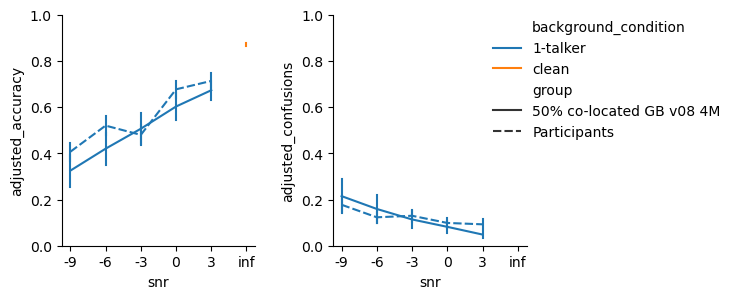

In [89]:
fig, axs = plt.subplots(1,2, figsize=(6,3))

g = sns.lineplot(data=gender_cond_df, x = 'snr', y = 'adjusted_accuracy', err_style='bars', errorbar=('se', 1),
                  style='group', #style_order=['Participants', 'CommonVoice', 'WordSpeakerNoise'], 
                  hue='background_condition', #palette=palette,
            ax=axs[0])

g1 = sns.lineplot(data=gender_cond_df, x = 'snr', y = 'adjusted_confusions',  err_style='bars', errorbar=('se', 1),
                   style='group', # style_order=['Participants', 'CommonVoice', 'WordSpeakerNoise'], 
                   hue='background_condition',# palette=palette,
            ax=axs[1])

g.set_xticks(ticks=x_tick_locs) # set new labels
g1.set_xticks(ticks=x_tick_locs) # set new labels
g.set_xticklabels(labels=x_tick_labels)
g1.set_xticklabels(labels=x_tick_labels)
g.set_ylim(0,1)
g1.set_ylim(0,1)
g.legend().remove()     
# add space between plots
plt.subplots_adjust(wspace=0.4)
sns.despine()

# remove legend titles 
g1.legend_.set_title('')
g1.legend(frameon=False, bbox_to_anchor=(.8, 1), loc=2, borderaxespad=0., title='')


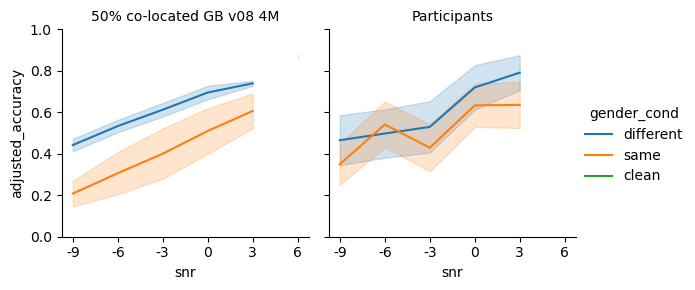

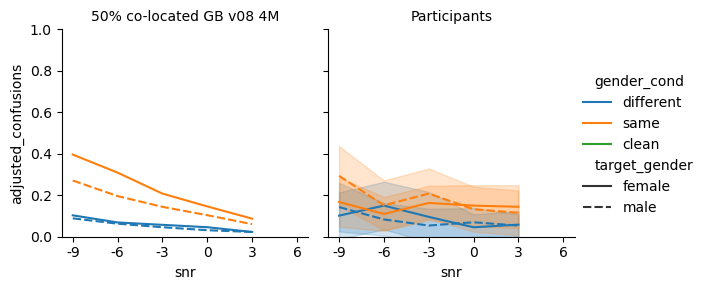

In [91]:
g = sns.relplot(data=gender_cond_df, x='snr', y='adjusted_accuracy', hue='gender_cond', kind='line', col='group',
                # style='target_gender',#col_order=['Participants', 'CommonVoice', 'WordSpeakerNoise'],
            #    markers="o", dashes=False, 
               errorbar=('se', 2), height=3)

x_tick_locs = gender_cond_df.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
# x_tick_labels[-1] = 'inf'
# set titles
g.set_titles("{col_name}")
for ax in g.axes.flat:
# labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)
    plt.ylim(0,1)


g = sns.relplot(data=gender_cond_df, x='snr', y='adjusted_confusions', hue='gender_cond', kind='line', col='group',#col_order=['Participants', 'CommonVoice', 'WordSpeakerNoise'],
            #    markers="o", dashes=False,
                style='target_gender',
                 errorbar=('se', 2), height=3)

x_tick_locs = gender_cond_df.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
# x_tick_labels[-1] = 'inf'
# set titles
g.set_titles("{col_name}")
for ax in g.axes.flat:
# labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)
    plt.ylim(0,1)


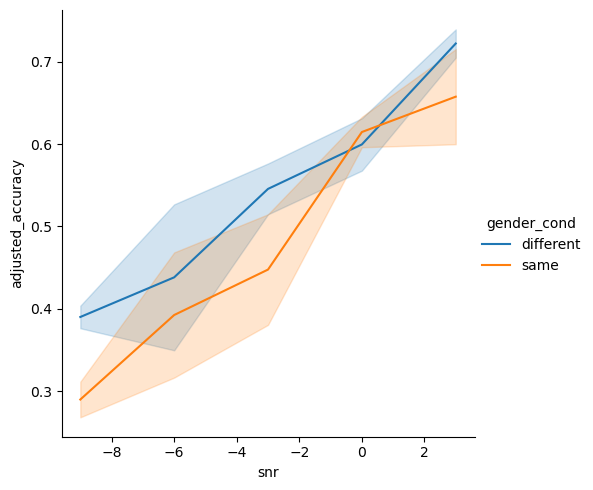

In [86]:
sns.relplot(data = f0_analysis_df.groupby(['snr', 'gender_cond', 'target_gender', 'background_condition']).agg({'adjusted_accuracy':'mean', 'adjusted_confusions':'mean'}).reset_index(),
x='snr', y='adjusted_accuracy', hue='gender_cond', kind='line')

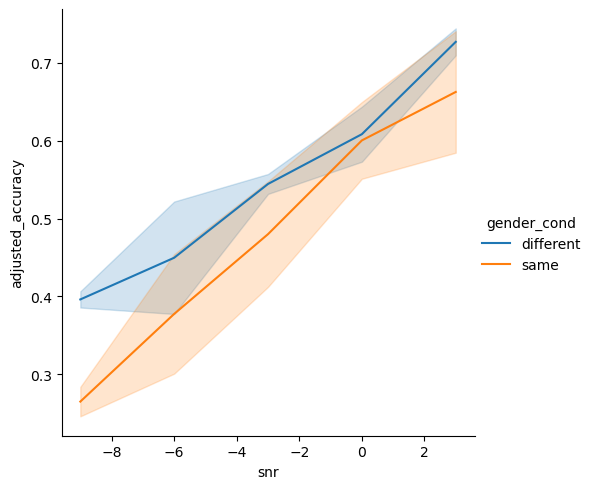

In [87]:
gender_cond_df[gender_cond_df.group == 'Participants'].groupby(['snr', 'gender_cond', 'target_gender', 'background_condition']).agg({'adjusted_accuracy':'mean', 'adjusted_confusions':'mean'}).reset_index()
sns.relplot(data =gender_cond_df[gender_cond_df.group == 'Participants'].groupby(['snr', 'gender_cond', 'target_gender', 'background_condition']).agg({'adjusted_accuracy':'mean', 'adjusted_confusions':'mean'}).reset_index(),
x='snr', y='adjusted_accuracy', hue='gender_cond', kind='line')

In [88]:
gender_cond_df[gender_cond_df.id_subject == "50% co-located GB v08 4M"]

,background_condition,snr,id_subject,gender_cond,target_gender,accuracy,confusions,adjusted_accuracy,adjusted_confusions,group
4,1-talker,-9,50% co-located GB v08 4M,different,female,0.412607,0.100287,0.426934,0.103152,50% co-located GB v08 4M
5,1-talker,-9,50% co-located GB v08 4M,different,male,0.448571,0.085714,0.457143,0.088571,50% co-located GB v08 4M
6,1-talker,-9,50% co-located GB v08 4M,same,female,0.165730,0.390449,0.176966,0.396067,50% co-located GB v08 4M
7,1-talker,-9,50% co-located GB v08 4M,same,male,0.230548,0.268012,0.239193,0.270893,50% co-located GB v08 4M
255,1-talker,-6,50% co-located GB v08 4M,different,female,0.510029,0.068768,0.518625,0.068768,50% co-located GB v08 4M
256,1-talker,-6,50% co-located GB v08 4M,different,male,0.540000,0.060000,0.548571,0.062857,50% co-located GB v08 4M
257,1-talker,-6,50% co-located GB v08 4M,same,female,0.244382,0.303371,0.255618,0.308989,50% co-located GB v08 4M
258,1-talker,-6,50% co-located GB v08 4M,same,male,0.348703,0.190202,0.357349,0.195965,50% co-located GB v08 4M
503,1-talker,-3,50% co-located GB v08 4M,different,female,0.587393,0.054441,0.595989,0.057307,50% co-located GB v08 4M
504,1-talker,-3,50% co-located GB v08 4M,different,male,0.617143,0.040000,0.628571,0.045714,50% co-located GB v08 4M


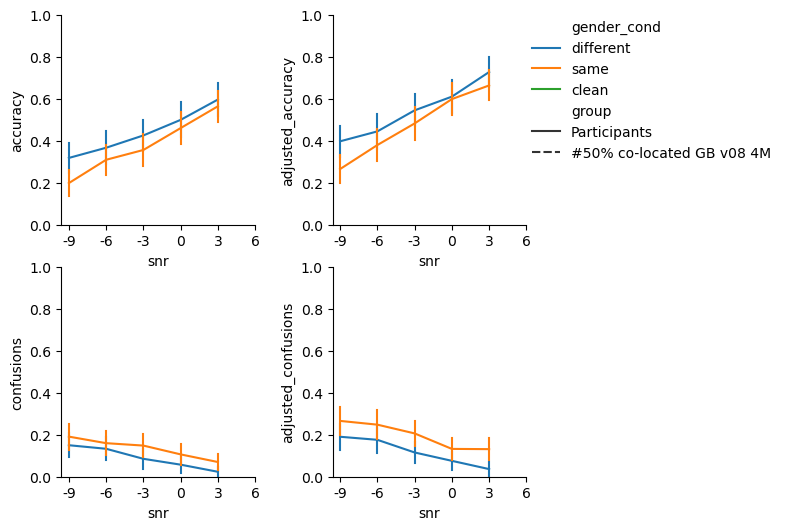

In [89]:
fig, axs = plt.subplots(2,2, figsize=(6,6))

# style order with participants first 
style_order = ['Participants', '#50% co-located GB v08 4M']

g = sns.lineplot(data=gender_cond_df, x = 'snr', y = 'accuracy', err_style='bars', errorbar=('se', 2),
                  style='group', style_order=style_order, 
                  hue='gender_cond',
            ax=axs[0,0])

g1 = sns.lineplot(data=gender_cond_df, x = 'snr', y = 'adjusted_accuracy',  err_style='bars', errorbar=('se', 2),
                   style='group', style_order=style_order, 
                  hue='gender_cond',
            ax=axs[0,1])
g2 = sns.lineplot(data=gender_cond_df, x = 'snr', y = 'confusions', err_style='bars', errorbar=('se', 2),
                  style='group', style_order=style_order, 
                  hue='gender_cond',
            ax=axs[1,0])

g3 = sns.lineplot(data=gender_cond_df, x = 'snr', y = 'adjusted_confusions',  err_style='bars', errorbar=('se', 2),
                   style='group', style_order=style_order, 
                  hue='gender_cond',
            ax=axs[1,1])

g.set_xticks(ticks=x_tick_locs) # set new labels
g1.set_xticks(ticks=x_tick_locs) # set new labels
g.set_xticklabels(labels=x_tick_labels)
g1.set_xticklabels(labels=x_tick_labels)
g2.set_xticks(ticks=x_tick_locs) # set new labels
g3.set_xticks(ticks=x_tick_locs) # set new labels
g2.set_xticklabels(labels=x_tick_labels)
g3.set_xticklabels(labels=x_tick_labels)
g.set_ylim(0,1)
g1.set_ylim(0,1)
g2.set_ylim(0,1)
g3.set_ylim(0,1)
g.legend().remove()     
g2.legend().remove()     
g3.legend().remove()     
# add space between plots
plt.subplots_adjust(wspace=0.4)
sns.despine()
# remove legend titles 

g1.legend_.set_title('')
g1.legend(frameon=False, bbox_to_anchor=(1, 1), loc=2, borderaxespad=0., title='')


/tmp/ipykernel_1775877/321950503.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot['group'] = to_plot.group.replace(plt_name_dict)
/tmp/ipykernel_1775877/321950503.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot.rename(columns={'target_gender': 'talker gender'}, inplace=True)


Text(0.5, 0.98, 'Effect of target gender on 1-talker same-gender distractor performance')

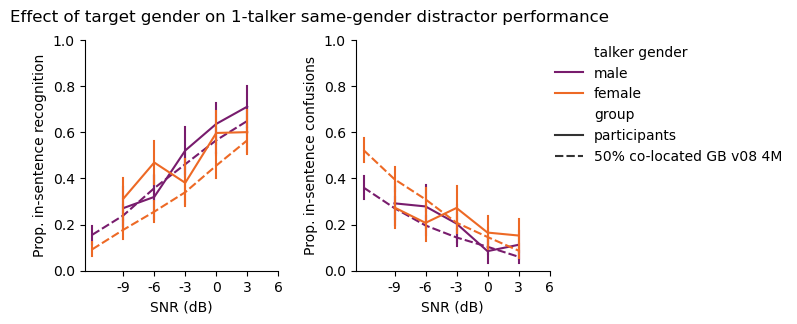

In [90]:
fig, axs = plt.subplots(1,2, figsize=(6,3))



to_plot = combined_f0_df[(combined_f0_df.gender_cond == 'same') ]

plt_name_dict = {
      # 'Binaural v08': "Train with normal spatialization", 
'Binaural CV no aug 50% co-located': "Train with 50% co-located",
            #     '70% same-sex distractor': 'Train with 70% same-sex distractor' ,
                'Baseline CNN':'Baseline CNN'}


to_plot['group'] = to_plot.group.replace(plt_name_dict)
style_order =  ["participants"] + list(plt_name_dict.values()) 

to_plot.rename(columns={'target_gender': 'talker gender'}, inplace=True)

g = sns.lineplot(data=to_plot, x = 'snr', y = 'adjusted_accuracy', err_style='bars', errorbar=('se', 2),
                  style='group', #style_order=style_order, 
                  hue='talker gender',palette='inferno',
            ax=axs[0])

g1 = sns.lineplot(data=to_plot, x = 'snr', y = 'adjusted_confusions',  err_style='bars', errorbar=('se', 2),
                   style='group',#style_order=style_order, 
                  hue='talker gender', palette='inferno',
            ax=axs[1])


g.set_xticks(ticks=x_tick_locs) # set new labels
g1.set_xticks(ticks=x_tick_locs) # set new labels
g.set_xticklabels(labels=x_tick_labels)
g1.set_xticklabels(labels=x_tick_labels)

g.set_ylim(0,1)
g1.set_ylim(0,1)

g.legend().remove()     
# g3.legend().remove()     
# add space between plots
plt.subplots_adjust(wspace=.4)
axs[0].set_xlabel("SNR (dB)")
axs[1].set_xlabel("SNR (dB)")

axs[0].set_ylabel("Prop. in-sentence recognition")
axs[1].set_ylabel("Prop. in-sentence confusions")
sns.despine()
# remove legend titles 
# g.legend(frameon=False, bbox_to_anchor=(1, 1), loc=2, borderaxespad=0., title='')
g1.legend(frameon=False, bbox_to_anchor=(1, 1), loc=2, borderaxespad=0.)

plt.suptitle("Effect of target gender on 1-talker same-gender distractor performance")

50% co-located GB v08 4M


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

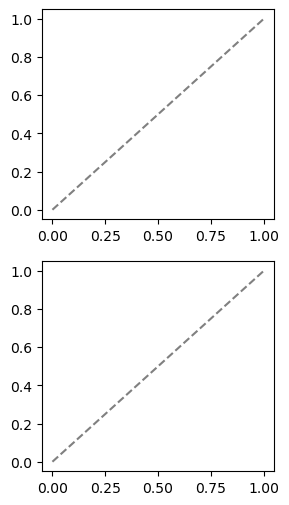

In [91]:


# plt_name_dict = {'Binaural CV no aug 50% co-located': "Best binaural model", "25% co-located LN last valid time no affine":"New layer ordering", 'Binaural v08': 'New binaural model'}
for_scatter = combined_f0_df.groupby(['background_condition', 'snr', 'group', 'gender_cond', 'target_gender']).agg(
	{'adjusted_accuracy':['mean', 'sem'], 'adjusted_confusions':['mean', 'sem']}).reset_index()
# flatten multi index
for_scatter.columns = ['background_condition', 'snr', 'group', 'gender_cond', 'target_gender', 
						'adjusted_accuracy', 'adj_acc_std_error', "adjusted_confusions", "adj_conf_std_error"]

to_plot = for_scatter[for_scatter.gender_cond == 'same'].copy() #[gender_cond_df.group.isin(list(plt_name_dict.keys()) + [""])]
hue_keys = to_plot.target_gender.unique()
# to_plot.rename(columns={'target_gender': 'talker gender'}, inplace=True)


palette = dict(zip(hue_keys, sns.color_palette("inferno", n_colors= len(hue_keys))))

x = y = np.linspace(0,1,5)

fontsize = 10

# model_list = ["Binaural CommonVoice", "Binaural Half-CoLocated CV", 'Mono CommonVoice', 'Diotic CommonVoice', 'Mono WordSpeakerNoise']
# model_list = to_plot.group.unique()[1:]
# model_list = ['Binaural v08']#, "25% co-located LN last valid time no affine"]

# model_list =  ['70% same-sex distractor'] #["v08 25% co-located"]
# model_list = ["25% co-located LN last valid time no affine"]

n_models = len(model_list)
fig, axs = plt.subplots(2, n_models, figsize=(3 * n_models, 6 ))


# for ix, group in enumerate(to_plot.group.unique()):
# add dashed line to each subplot 
for ax in axs.flat:
    ax.plot(x,y, ls='dashed', color='grey')

human_df = to_plot[to_plot.group == f'participants']
hue_order = ['male', 'female']


for ix, model in enumerate(model_list):
    print(model)
    
    model_df = to_plot[to_plot.group == model]
    # summarize model data

    for condition in hue_order:
        # print(condition)
        # plot acc 
        human_data = human_df[human_df.target_gender == condition]
        human_means = human_data["adjusted_accuracy"].values
        human_errors = human_data["adj_acc_std_error"].values

        model_data = model_df[model_df.target_gender == condition]
        model_means = model_data["adjusted_accuracy"].values
        model_errors = model_data["adj_acc_std_error"].values
        
        # mult error by 2 for 2 sem 
        axs[0, ix].errorbar(x=human_means, y=model_means, xerr=human_errors*2, yerr=model_errors*2, marker='o', linestyle='-', ms=3, elinewidth=2.5, label= condition,
                             color=palette[condition])#, mfc=palette[condition], mec=palette[condition])
        
        # human confs 
        human_conf_means = human_data["adjusted_confusions"].values
        human_conf_errors = human_data["adj_conf_std_error"].values

        # model adjusted_confusions
        model_conf_means = model_data["adjusted_confusions"].values
        model_conf_errors = model_data["adj_conf_std_error"].values

        axs[1, ix].errorbar(x=human_conf_means, y=model_conf_means, xerr=human_conf_errors*2, yerr=model_conf_errors*2, marker='o', linestyle='-', ms=3, elinewidth=2.5, label= "1-talker",
                               color=palette[condition] )
    
    axs[0,ix].set_title(model, fontsize=fontsize)

    # Add error annotations 
    # acc errors 
    res = stats.spearmanr(human_df["adjusted_accuracy"].values,  model_df['adjusted_accuracy'].values)
    rho = res.correlation
    axs[0, ix].annotate(f"$Rho$ = {rho:.2f}", (0.6, 0.11), fontsize=fontsize)
    samp_rmse = np.sqrt(np.mean((human_df["adjusted_accuracy"].values - model_df['adjusted_accuracy'].values)**2))
    axs[0, ix].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.6, 0.05), fontsize=fontsize)
    # conf errors
    res = stats.spearmanr(human_conf_means, model_conf_means)
    rho = res.correlation
    axs[1, ix].annotate(f"$Rho$ = {rho:.2f}", (0.6, 0.11), fontsize=fontsize)   # old xy coords ( 0.25, 0.05)
    samp_rmse = np.sqrt(np.mean((human_conf_means - model_conf_means)**2))
    axs[1, ix].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.6, 0.05), fontsize=fontsize) # old xy coords ( 0.25, 0.025)
    # add tiles 
#         axs[0].set_title(plt_name_dict[model], fontsize=fontsize)
    axs[0, ix].set_xlabel(f"Human prop. correct", fontsize=fontsize)
    axs[1, ix].set_xlabel(f"Human prop. confusions", fontsize=fontsize)

    
# set first row x and y limits to 0 1
for ax in axs.flat:
    ax.set_xlim(0,1)
    ax.set_ylim(0,1)

axs[0,0].set_ylabel(f"Model prop. correct", fontsize=fontsize)
axs[1,0].set_ylabel(f"Model prop. confusions", fontsize=fontsize)


sns.despine()
lines_labels = [ax.get_legend_handles_labels() for ax in [axs[0,0]]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
plt.subplots_adjust(hspace=0.3)

fig.legend(lines, hue_order, bbox_transform=fig.transFigure, ncol=3,
           title='Shared talker sex',  bbox_to_anchor=(0.65, 0),)
# plt.tight_layout()
# 

# plt.suptitle(f"Binaural model match to human performance using in-sentence scoring", y=0.95)



In [ ]:

gender_cond_df = (combined_f0_df.groupby(["background_condition", "snr", 'group', "gender_cond"])
                     .agg({"accuracy":"mean",
                           'confusions':'mean', 
                           "adjusted_accuracy":["mean", "sem"],
                           "adjusted_confusions": ["mean", "sem"]})
                     .reset_index())

gender_cond_df.columns = ['background_condition','snr', "group", "gender_cond",
                          'accuracy_mean', 'confusions_mean',
                           'adjusted_accuracy', 'adj_acc_std_error',
                           'adjusted_confusions', 'adj_conf_std_error']



50% co-located GB v08 4M
50% co-located v07
50% co-located v08 4M
Baseline CNN
Standard v08


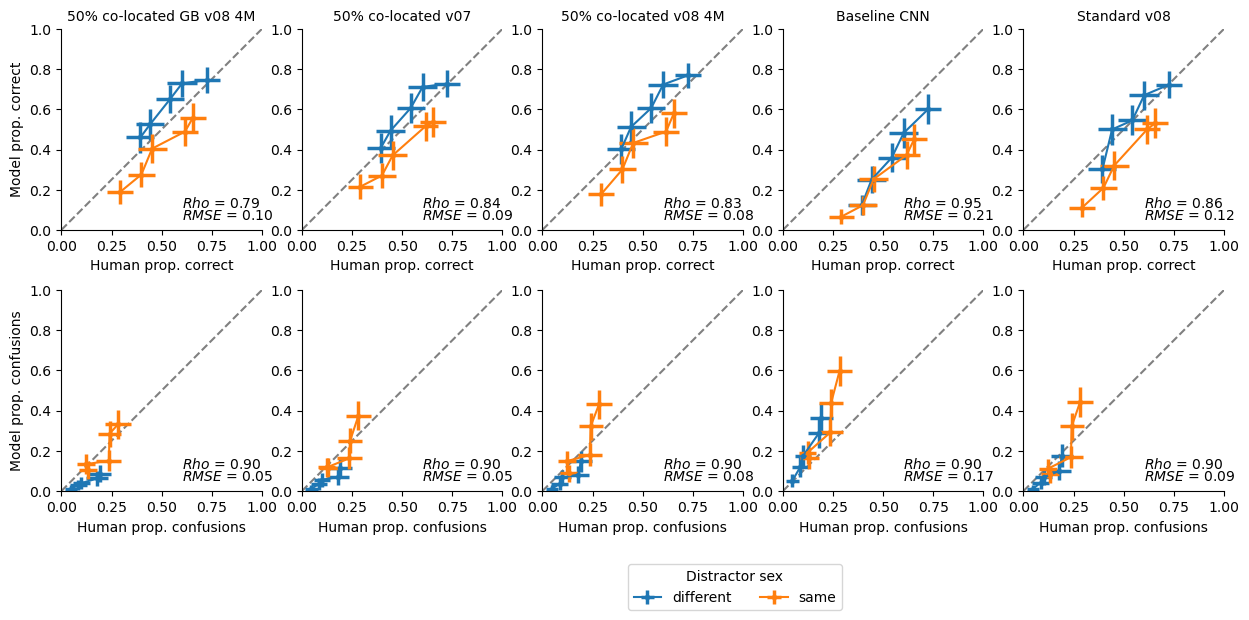

In [ ]:


# plt_name_dict = {'Binaural CV no aug 50% co-located': "Best binaural model", "25% co-located LN last valid time no affine":"New layer ordering", 'Binaural v08': 'New binaural model'}


to_plot = gender_cond_df#[gender_cond_df.group.isin(list(plt_name_dict.keys()) + [""])]
model_list = to_plot.group.unique()[:-1]

palette = dict(zip(hue_order, sns.color_palette(n_colors= len(hue_order), as_cmap=True)))

x = y = np.linspace(0,1,5)

fontsize = 10

# model_list = ["Binaural CommonVoice", "Binaural Half-CoLocated CV", 'Mono CommonVoice', 'Diotic CommonVoice', 'Mono WordSpeakerNoise']
# model_list = to_plot.group.unique()[1:]
# model_list = ['Binaural v08']#, "25% co-located LN last valid time no affine"]

# model_list =  ['70% same-sex distractor'] #["v08 25% co-located"]
# model_list = ["25% co-located LN last valid time no affine"]

n_models = len(model_list)
fig, axs = plt.subplots(2, n_models, figsize=(3 * n_models, 6 ))


# for ix, group in enumerate(to_plot.group.unique()):
# add dashed line to each subplot 
for ax in axs.flat:
    ax.plot(x,y, ls='dashed', color='grey')

human_df = to_plot[to_plot.group == f'participants']
hue_order = ['different', 'same']


for ix, model in enumerate(model_list):
    print(model)
    
    model_df = to_plot[to_plot.group == model]
    # summarize model data

    for condition in hue_order:
        # print(condition)
        # plot acc 
        human_data = human_df[human_df.gender_cond == condition]
        human_means = human_data["adjusted_accuracy"].values
        human_errors = human_data["adj_acc_std_error"].values

        model_data = model_df[model_df.gender_cond == condition]
        model_means = model_data["adjusted_accuracy"].values
        model_errors = model_data["adj_acc_std_error"].values
        
        # mult error by 2 for 2 sem 
        axs[0, ix].errorbar(x=human_means, y=model_means, xerr=human_errors*2, yerr=model_errors*2, marker='o', linestyle='-', ms=3, elinewidth=2.5, label= condition,
                            )#, mfc=palette[condition], mec=palette[condition])
        
        # human confs 
        human_conf_means = human_data["adjusted_confusions"].values
        human_conf_errors = human_data["adj_conf_std_error"].values

        # model adjusted_confusions
        model_conf_means = model_data["adjusted_confusions"].values
        model_conf_errors = model_data["adj_conf_std_error"].values

        axs[1, ix].errorbar(x=human_conf_means, y=model_conf_means, xerr=human_conf_errors*2, yerr=model_conf_errors*2, marker='o', linestyle='-', ms=3, elinewidth=2.5, label= "1-talker",
                                )
    
    axs[0,ix].set_title(model, fontsize=fontsize)

    # Add error annotations 
    # acc errors 
    res = stats.spearmanr(human_df["adjusted_accuracy"].values,  model_df['adjusted_accuracy'].values)
    rho = res.correlation
    axs[0, ix].annotate(f"$Rho$ = {rho:.2f}", (0.6, 0.11), fontsize=fontsize)
    samp_rmse = np.sqrt(np.mean((human_df["adjusted_accuracy"].values - model_df['adjusted_accuracy'].values)**2))
    axs[0, ix].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.6, 0.05), fontsize=fontsize)
    # conf errors
    res = stats.spearmanr(human_conf_means, model_conf_means)
    rho = res.correlation
    axs[1, ix].annotate(f"$Rho$ = {rho:.2f}", (0.6, 0.11), fontsize=fontsize)   # old xy coords ( 0.25, 0.05)
    samp_rmse = np.sqrt(np.mean((human_conf_means - model_conf_means)**2))
    axs[1, ix].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.6, 0.05), fontsize=fontsize) # old xy coords ( 0.25, 0.025)
    # add tiles 
#         axs[0].set_title(plt_name_dict[model], fontsize=fontsize)
    axs[0, ix].set_xlabel(f"Human prop. correct", fontsize=fontsize)
    axs[1, ix].set_xlabel(f"Human prop. confusions", fontsize=fontsize)

    
# set first row x and y limits to 0 1
for ax in axs.flat:
    ax.set_xlim(0,1)
    ax.set_ylim(0,1)

axs[0,0].set_ylabel(f"Model prop. correct", fontsize=fontsize)
axs[1,0].set_ylabel(f"Model prop. confusions", fontsize=fontsize)


sns.despine()
lines_labels = [ax.get_legend_handles_labels() for ax in [axs[0,0]]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
plt.subplots_adjust(hspace=0.3)

fig.legend(lines, hue_order, bbox_transform=fig.transFigure, ncol=3,
           title='Distractor sex',  bbox_to_anchor=(0.65, 0),)
# plt.tight_layout()
# 

# plt.suptitle(f"Binaural model match to human performance using in-sentence scoring", y=0.95)

